### Install libraries


In [268]:
# %pip install missingno
# ! pip install xgboost

### import libs

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [270]:
pd.set_option('display.max_columns', None)

In [7]:
import os

file_path = os.path.join('..', 'datasets', 'support2_dataset.csv')
raw_data = pd.read_csv(file_path)



In [8]:
raw_data

,age,sex,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,...,ph,glucose,bun,urine,adlp,adls,adlsc,death,hospdead,sfdm2
0,62.84998,male,Lung Cancer,Cancer,0,11.0,$11-$25k,0.0,9715.0,NaN,...,7.459961,NaN,NaN,NaN,7.0,7.0,7.000000,0,0,NaN
1,60.33899,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,$11-$25k,44.0,34496.0,NaN,...,7.250000,NaN,NaN,NaN,NaN,1.0,1.000000,1,1,<2 mo. follow-up
2,52.74698,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,under $11k,0.0,41094.0,NaN,...,7.459961,NaN,NaN,NaN,1.0,0.0,0.000000,1,0,<2 mo. follow-up
3,42.38498,female,Lung Cancer,Cancer,2,11.0,under $11k,0.0,3075.0,NaN,...,NaN,NaN,NaN,NaN,0.0,0.0,0.000000,1,0,no(M2 and SIP pres)
4,79.88495,female,ARF/MOSF w/Sepsis,ARF/MOSF,1,NaN,NaN,26.0,50127.0,NaN,...,7.509766,NaN,NaN,NaN,NaN,2.0,2.000000,0,0,no(M2 and SIP pres)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9100,66.07300,male,ARF/MOSF w/Sepsis,ARF/MOSF,1,8.0,NaN,0.0,52870.0,34329.3125,...,7.459961,188.0,21.0,NaN,NaN,0.0,0.000000,0,0,NaN
9101,55.15399,female,Coma,Coma,1,11.0,NaN,41.0,35377.0,23558.5000,...,7.289062,190.0,49.0,0.0,NaN,0.0,0.000000,0,0,NaN
9102,70.38196,male,ARF/MOSF w/Sepsis,ARF/MOSF,1,NaN,NaN,0.0,46564.0,31409.0156,...,7.379883,189.0,60.0,3900.0,NaN,NaN,2.525391,0,0,NaN
9103,47.01999,male,MOSF w/Malig,ARF/MOSF,1,13.0,NaN,0.0,58439.0,NaN,...,7.469727,246.0,55.0,NaN,NaN,0.0,0.000000,1,1,<2 mo. follow-up


In [273]:
raw_data.isnull().sum()

age            0
sex            0
dzgroup        0
dzclass        0
num.co         0
edu         1634
income      2982
scoma          1
charges      172
totcst       888
totmcst     3475
avtisst       82
race          42
sps            1
aps            1
surv2m         1
surv6m         1
hday           0
diabetes       0
dementia       0
ca             0
prg2m       1649
prg6m       1633
dnr           30
dnrday        30
meanbp         1
wblc         212
hrt            1
resp           1
temp           1
pafi        2325
alb         3372
bili        2601
crea          67
sod            1
ph          2284
glucose     4500
bun         4352
urine       4862
adlp        5641
adls        2867
adlsc          0
death          0
hospdead       0
sfdm2       1400
dtype: int64

In [274]:
raw_data['sfdm2'].unique()

<ArrowStringArray>
[                  nan,    '<2 mo. follow-up', 'no(M2 and SIP pres)',
             'SIP>=30', 'adl>=4 (>=5 if sur)',       'Coma or Intub']
Length: 6, dtype: str

In [275]:
data_rm_dl = raw_data.copy()


### drop columns which give future information

In [276]:
data_rm_dl.drop(columns=['surv2m','death','hospdead','sfdm2','prg2m','prg6m'], inplace=True)

In [277]:
data_rm_dl.isnull().sum()

age            0
sex            0
dzgroup        0
dzclass        0
num.co         0
edu         1634
income      2982
scoma          1
charges      172
totcst       888
totmcst     3475
avtisst       82
race          42
sps            1
aps            1
surv6m         1
hday           0
diabetes       0
dementia       0
ca             0
dnr           30
dnrday        30
meanbp         1
wblc         212
hrt            1
resp           1
temp           1
pafi        2325
alb         3372
bili        2601
crea          67
sod            1
ph          2284
glucose     4500
bun         4352
urine       4862
adlp        5641
adls        2867
adlsc          0
dtype: int64

### According to the HBiostat Repository (https://hbiostat.org/data/repo/supportdesc, Professor Frank Harrell) the following default values have been found to be useful in imputing missing baseline physiologic data:
### Baseline Variablex	Normal Fill-in Value
- Serum albumin (alb)	3.5
- PaO2/FiO2 ratio (pafi) 	333.3
- Bilirubin (bili)	1.01
- Creatinine (crea)	1.01
- bun	6.51
- White blood count (wblc)	9 (thousands)
- Urine output (urine)	2502

In [278]:
data_rm_dl['alb']   = data_rm_dl['alb'].fillna(3.5)
data_rm_dl['pafi']  = data_rm_dl['pafi'].fillna(333.3)
data_rm_dl['bili']  = data_rm_dl['bili'].fillna(1.01)
data_rm_dl['crea']  = data_rm_dl['crea'].fillna(1.01)
data_rm_dl['bun']   = data_rm_dl['bun'].fillna(6.51)
data_rm_dl['wblc']  = data_rm_dl['wblc'].fillna(9)
data_rm_dl['urine'] = data_rm_dl['urine'].fillna(2502)


In [279]:
data_rm_dl

,age,sex,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,totmcst,avtisst,race,sps,aps,surv6m,hday,diabetes,dementia,ca,dnr,dnrday,meanbp,wblc,hrt,resp,temp,pafi,alb,bili,crea,sod,ph,glucose,bun,urine,adlp,adls,adlsc
0,62.84998,male,Lung Cancer,Cancer,0,11.0,$11-$25k,0.0,9715.0,NaN,NaN,7.000000,other,33.898438,20.0,0.036995,1,0,0,metastatic,no dnr,5.0,97.0,6.000000,69.0,22.0,36.00000,388.00000,1.799805,0.199982,1.199951,141.0,7.459961,NaN,6.51,2502.0,7.0,7.0,7.000000
1,60.33899,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,$11-$25k,44.0,34496.0,NaN,NaN,29.000000,white,52.695312,74.0,0.000000,3,0,0,no,NaN,NaN,43.0,17.097656,112.0,34.0,34.59375,98.00000,3.500000,1.010000,5.500000,132.0,7.250000,NaN,6.51,2502.0,NaN,1.0,1.000000
2,52.74698,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,under $11k,0.0,41094.0,NaN,NaN,13.000000,white,20.500000,45.0,0.664917,4,0,0,no,no dnr,17.0,70.0,8.500000,88.0,28.0,37.39844,231.65625,3.500000,2.199707,2.000000,134.0,7.459961,NaN,6.51,2502.0,1.0,0.0,0.000000
3,42.38498,female,Lung Cancer,Cancer,2,11.0,under $11k,0.0,3075.0,NaN,NaN,7.000000,white,20.097656,19.0,0.411987,1,0,0,metastatic,no dnr,3.0,75.0,9.099609,88.0,32.0,35.00000,333.30000,3.500000,1.010000,0.799927,139.0,NaN,NaN,6.51,2502.0,0.0,0.0,0.000000
4,79.88495,female,ARF/MOSF w/Sepsis,ARF/MOSF,1,NaN,NaN,26.0,50127.0,NaN,NaN,18.666656,white,23.500000,30.0,0.532959,3,0,0,no,no dnr,16.0,59.0,13.500000,112.0,20.0,37.89844,173.31250,3.500000,1.010000,0.799927,143.0,7.509766,NaN,6.51,2502.0,NaN,2.0,2.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9100,66.07300,male,ARF/MOSF w/Sepsis,ARF/MOSF,1,8.0,NaN,0.0,52870.0,34329.3125,32042.7500,20.333328,white,16.296875,22.0,0.801880,13,0,0,no,no dnr,23.0,109.0,7.399414,104.0,22.0,35.69531,280.00000,3.699707,0.399963,1.099854,131.0,7.459961,188.0,21.00,2502.0,NaN,0.0,0.000000
9101,55.15399,female,Coma,Coma,1,11.0,NaN,41.0,35377.0,23558.5000,22131.0469,18.000000,white,25.796875,31.0,0.485962,1,0,0,no,no dnr,29.0,43.0,9.000000,0.0,8.0,38.59375,218.50000,3.500000,1.010000,5.899414,135.0,7.289062,190.0,49.00,0.0,NaN,0.0,0.000000
9102,70.38196,male,ARF/MOSF w/Sepsis,ARF/MOSF,1,NaN,NaN,0.0,46564.0,31409.0156,31131.2500,23.000000,white,22.699219,39.0,0.660889,18,0,0,no,no dnr,8.0,111.0,8.398438,83.0,24.0,36.69531,180.00000,3.500000,0.399963,2.699707,139.0,7.379883,189.0,60.00,3900.0,NaN,NaN,2.525391
9103,47.01999,male,MOSF w/Malig,ARF/MOSF,1,13.0,NaN,0.0,58439.0,NaN,NaN,35.500000,white,40.195312,51.0,0.091995,22,0,0,yes,dnr after sadm,5.0,99.0,7.599609,110.0,24.0,36.39844,428.56250,1.199951,0.399963,3.500000,135.0,7.469727,246.0,55.00,2502.0,NaN,0.0,0.000000


In [280]:
data_rm_dl.isnull().sum()

age            0
sex            0
dzgroup        0
dzclass        0
num.co         0
edu         1634
income      2982
scoma          1
charges      172
totcst       888
totmcst     3475
avtisst       82
race          42
sps            1
aps            1
surv6m         1
hday           0
diabetes       0
dementia       0
ca             0
dnr           30
dnrday        30
meanbp         1
wblc           0
hrt            1
resp           1
temp           1
pafi           0
alb            0
bili           0
crea           0
sod            1
ph          2284
glucose     4500
bun            0
urine          0
adlp        5641
adls        2867
adlsc          0
dtype: int64

### Missingness Heatmap

<Axes: >

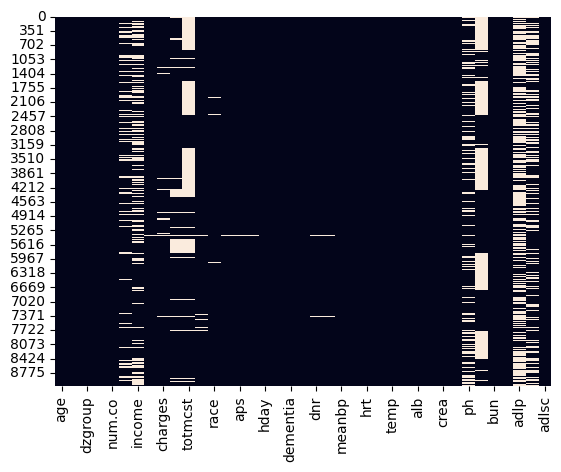

In [281]:
import seaborn as sns
sns.heatmap(data_rm_dl.isnull(), cbar=False)

### Correlation of Missingness: Check if the absence of one variable predicts the absence of another.

<Axes: >

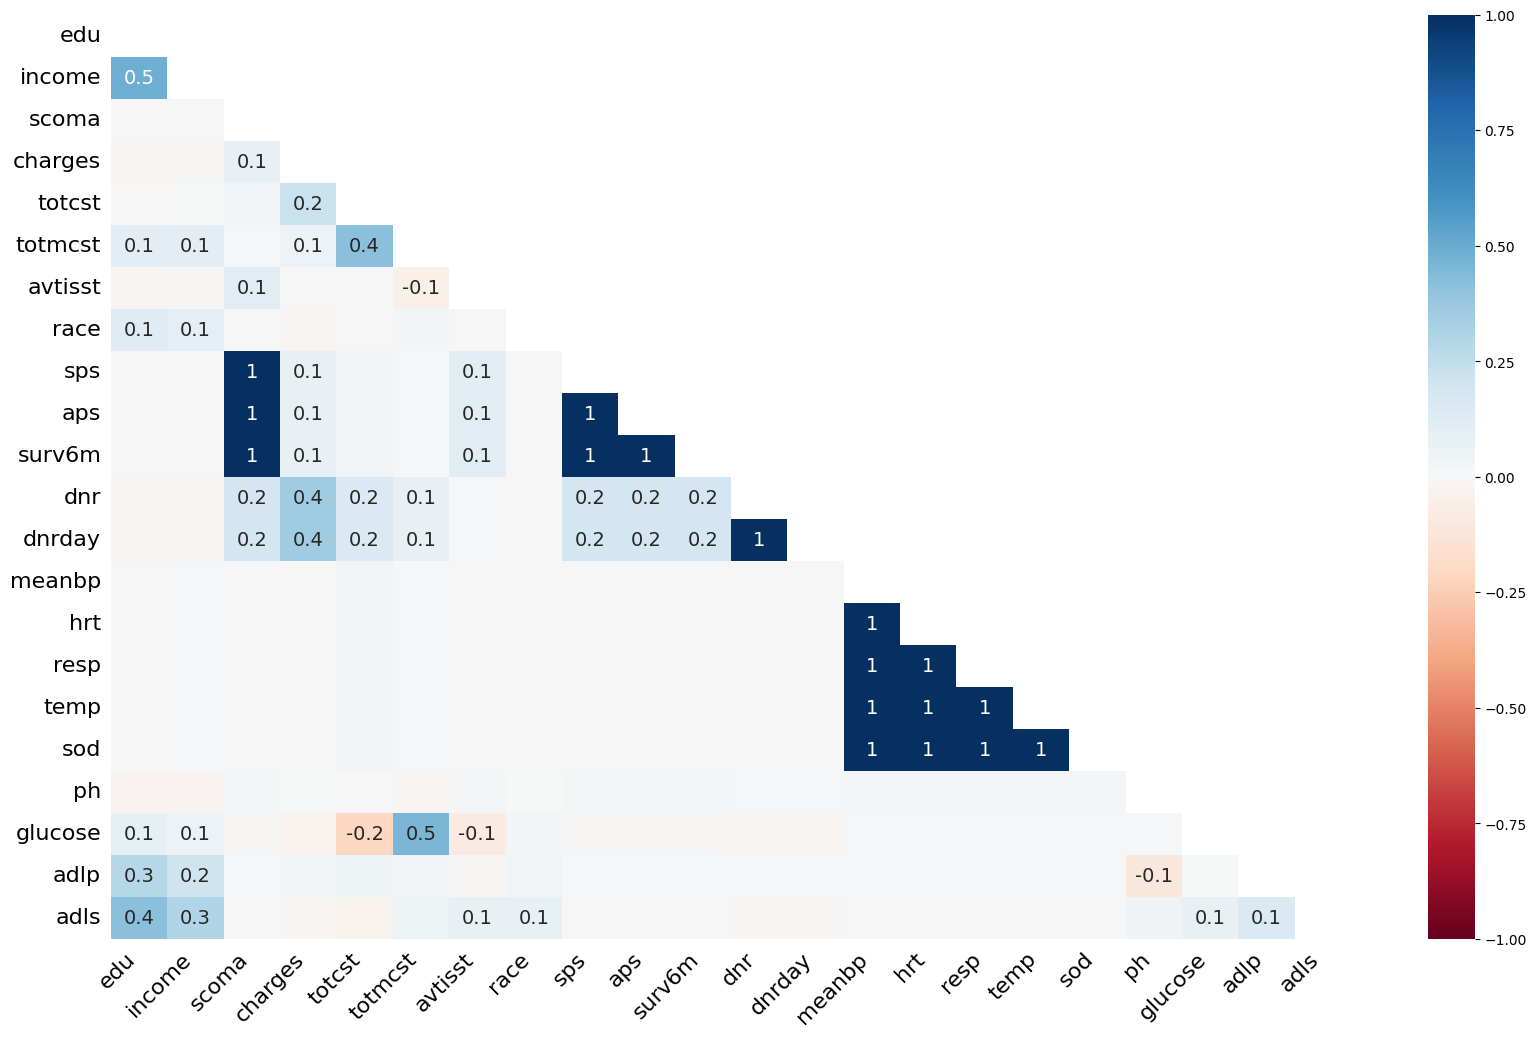

In [282]:
import missingno as msno
msno.heatmap(data_rm_dl)

### Numerical Summary:
Get the exact percentages to prioritize cleaning.

### The variables adlp (62% missing), adls (31% missing), and income (33% missing) show moderate positive correlations in their missingness (around 0.3 to 0.5).

Interpretation: These are likely socioeconomic or functional status indicators. If a patient was unable to provide information for one (e.g., ADL - Activities of Daily Living), they were likely unable to provide the others.

In [283]:
# Calculate missing percentage
missing_pct = data_rm_dl.isnull().mean() * 100

# Filter only columns with missing values
missing_cols = missing_pct[missing_pct > 0].index

# Print missing % and datatype for these columns
for col in missing_cols:
    print(f"{col}: {missing_pct[col]:.2f}% missing, dtype = {data_rm_dl[col].dtype}")

edu: 17.95% missing, dtype = float64
income: 32.75% missing, dtype = str
scoma: 0.01% missing, dtype = float64
charges: 1.89% missing, dtype = float64
totcst: 9.75% missing, dtype = float64
totmcst: 38.17% missing, dtype = float64
avtisst: 0.90% missing, dtype = float64
race: 0.46% missing, dtype = str
sps: 0.01% missing, dtype = float64
aps: 0.01% missing, dtype = float64
surv6m: 0.01% missing, dtype = float64
dnr: 0.33% missing, dtype = str
dnrday: 0.33% missing, dtype = float64
meanbp: 0.01% missing, dtype = float64
hrt: 0.01% missing, dtype = float64
resp: 0.01% missing, dtype = float64
temp: 0.01% missing, dtype = float64
sod: 0.01% missing, dtype = float64
ph: 25.09% missing, dtype = float64
glucose: 49.42% missing, dtype = float64
adlp: 61.95% missing, dtype = float64
adls: 31.49% missing, dtype = float64


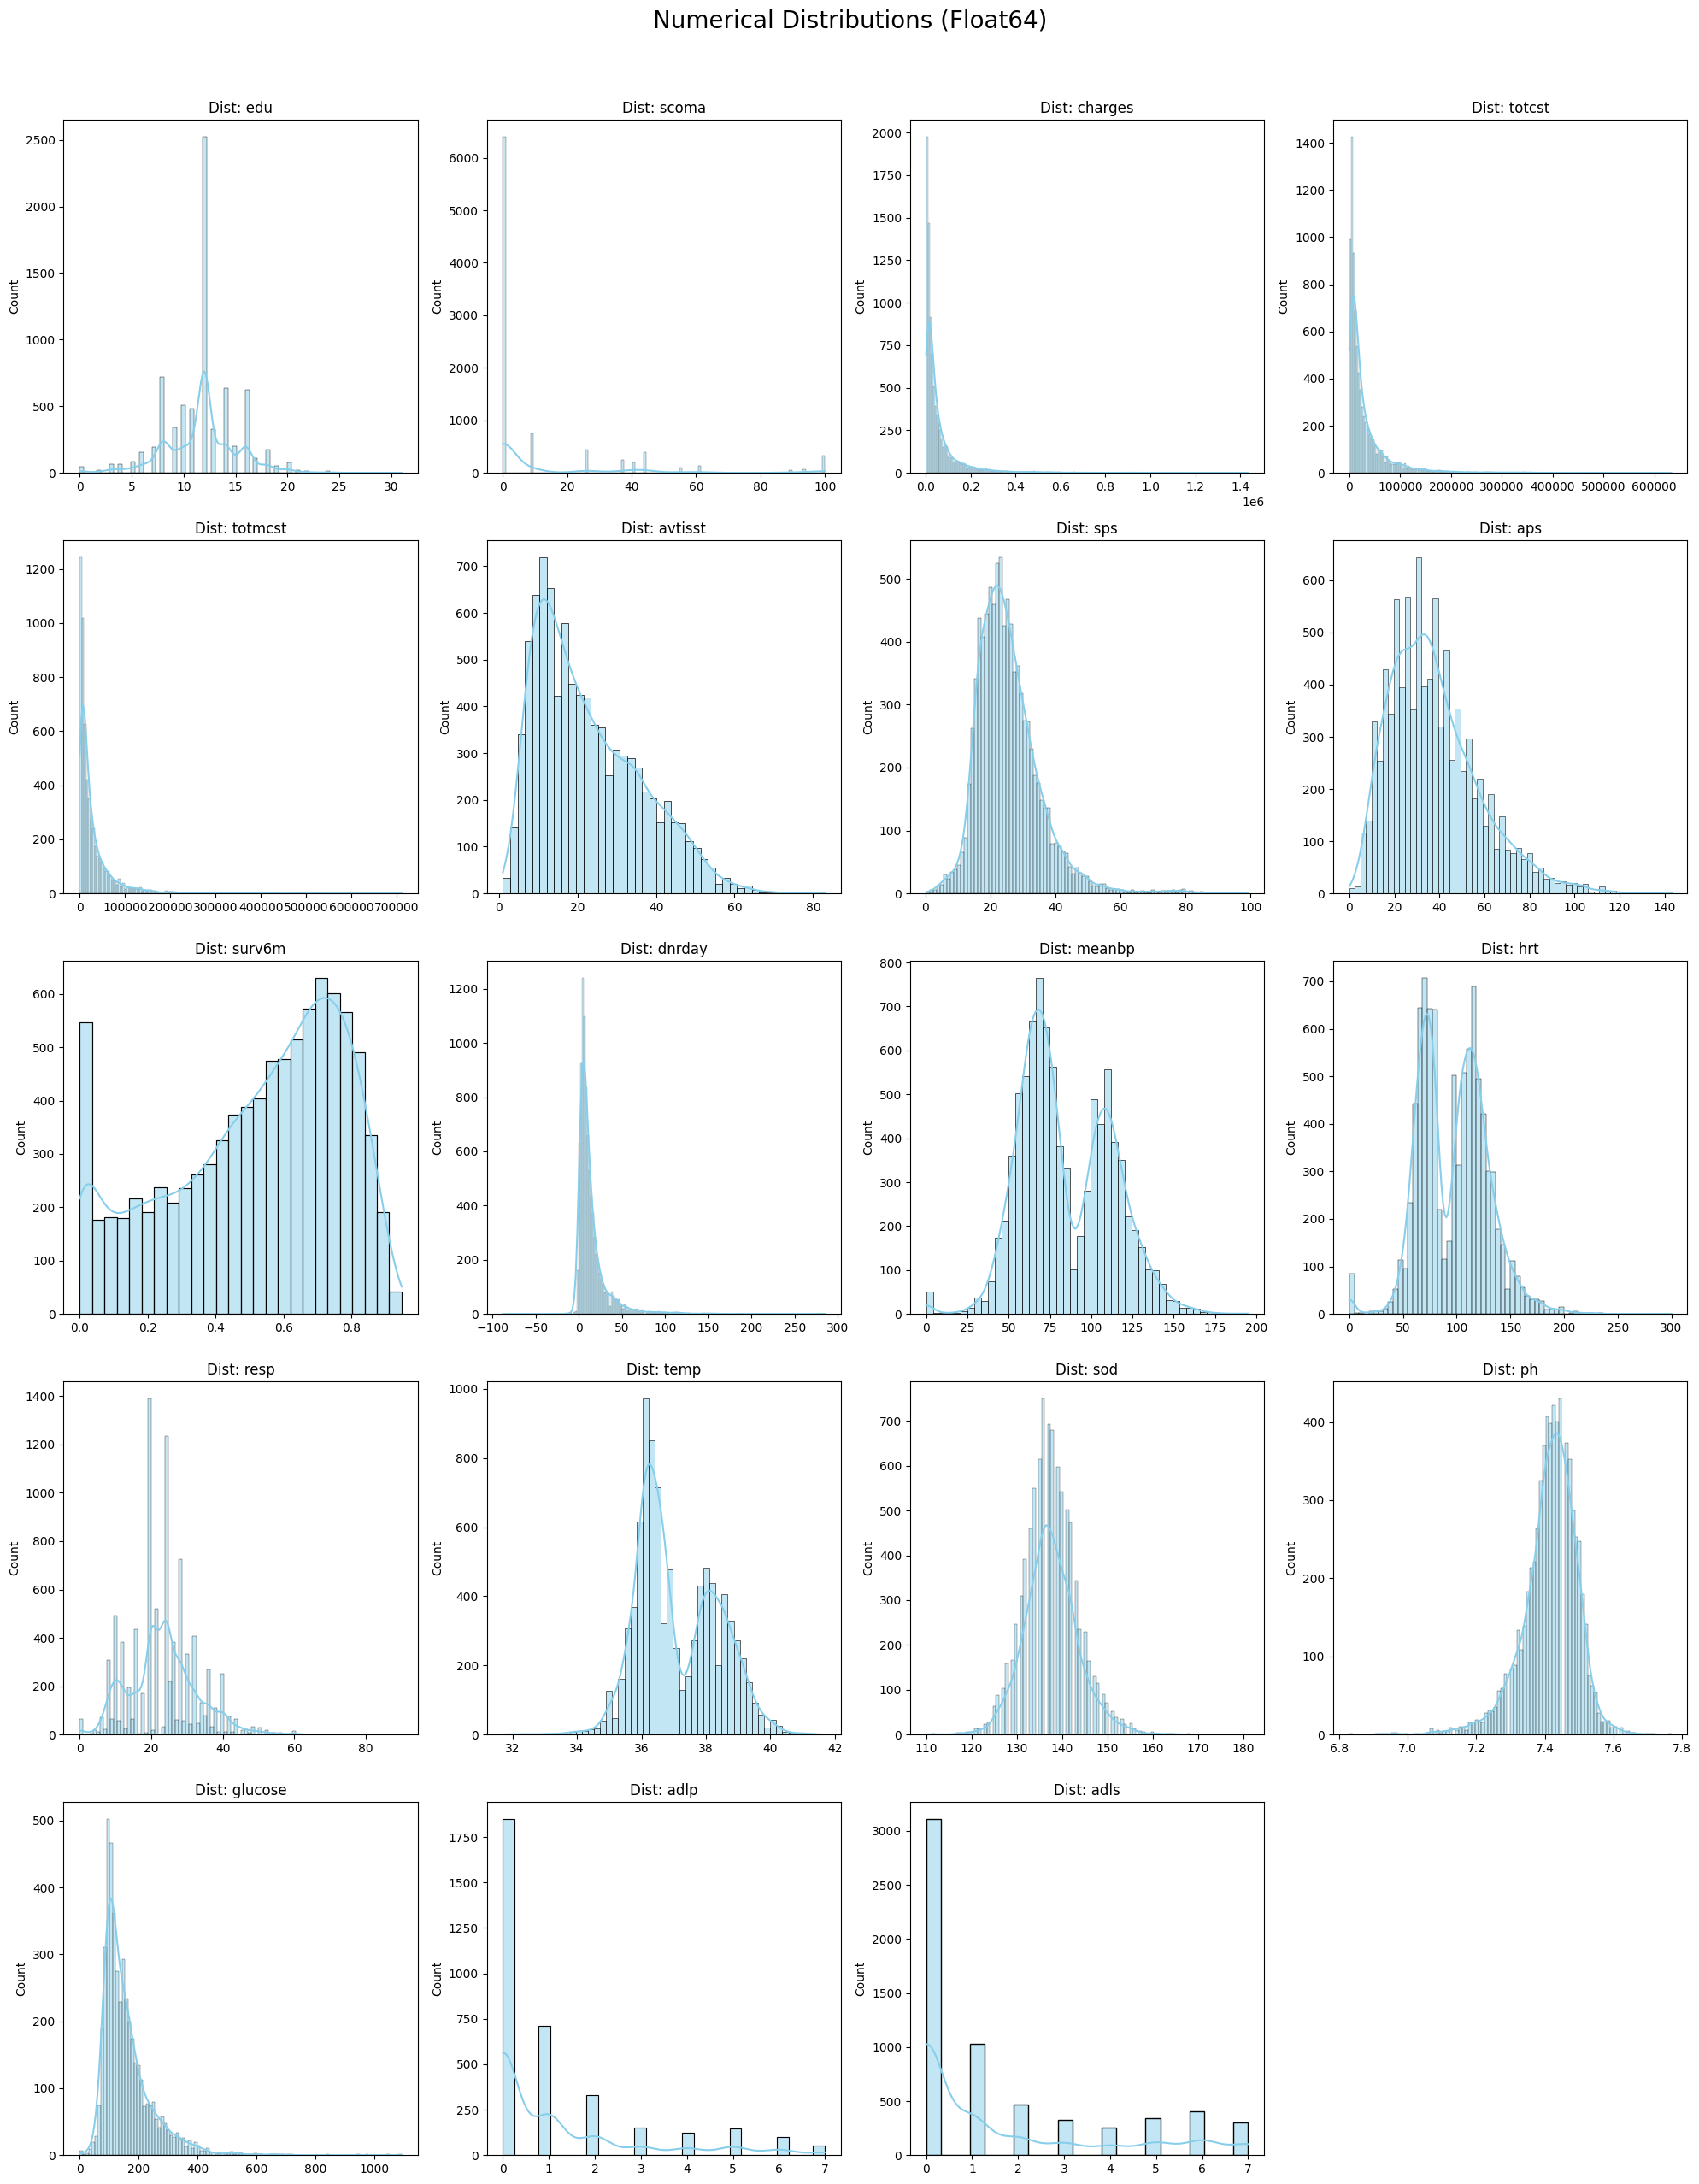

C:\Users\abdul\AppData\Local\Temp\ipykernel_10824\3724517944.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data_rm_dl[col].dropna(), palette='viridis')
C:\Users\abdul\AppData\Local\Temp\ipykernel_10824\3724517944.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data_rm_dl[col].dropna(), palette='viridis')
C:\Users\abdul\AppData\Local\Temp\ipykernel_10824\3724517944.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data_rm_dl[col].dropna(), palette='viridis')


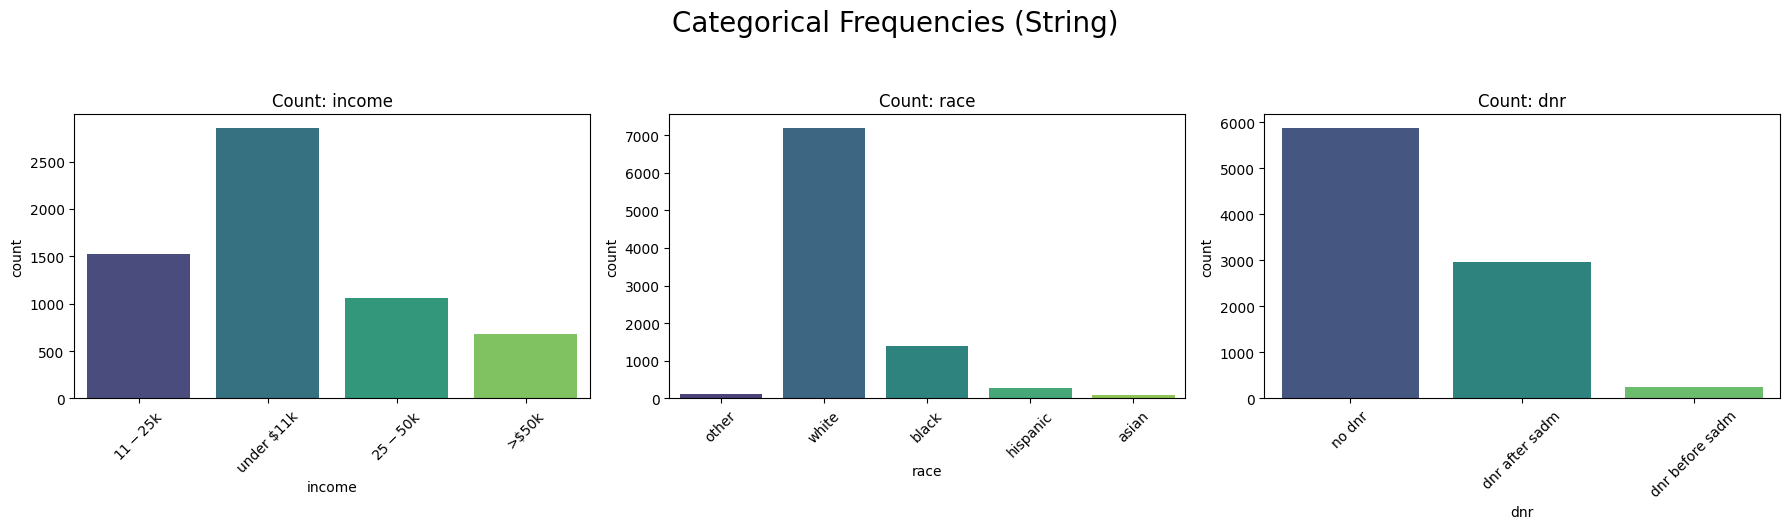

In [284]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Categorizing based on your provided info
num_cols = [
    'edu', 'scoma', 'charges', 'totcst', 'totmcst', 'avtisst', 
    'sps', 'aps', 'surv6m', 'dnrday', 'meanbp', 'hrt', 
    'resp', 'temp', 'sod', 'ph', 'glucose', 'adlp', 'adls'
]
cat_cols = ['income', 'race', 'dnr']

# 1. Plotting Numerical Distributions
n_num = len(num_cols)
cols_per_row = 4
rows = math.ceil(n_num / cols_per_row)

plt.figure(figsize=(20, 5 * rows))
for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    # Using Histplot with KDE to see the "shape" of the data
    sns.histplot(data_rm_dl[col].dropna(), kde=True, color='skyblue')
    plt.title(f'Dist: {col}')
    plt.xlabel('')

plt.suptitle('Numerical Distributions (Float64)', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

# 2. Plotting Categorical Distributions
plt.figure(figsize=(18, 5))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(1, 3, i)
    # Count plot for strings
    sns.countplot(x=data_rm_dl[col].dropna(), palette='viridis')
    plt.title(f'Count: {col}')
    plt.xticks(rotation=45)

plt.suptitle('Categorical Frequencies (String)', fontsize=20, y=1.05)
plt.tight_layout()
plt.show()

In [285]:
data_rm_dl.dtypes

age         float64
sex             str
dzgroup         str
dzclass         str
num.co        int64
edu         float64
income          str
scoma       float64
charges     float64
totcst      float64
totmcst     float64
avtisst     float64
race            str
sps         float64
aps         float64
surv6m      float64
hday          int64
diabetes      int64
dementia      int64
ca              str
dnr             str
dnrday      float64
meanbp      float64
wblc        float64
hrt         float64
resp        float64
temp        float64
pafi        float64
alb         float64
bili        float64
crea        float64
sod         float64
ph          float64
glucose     float64
bun         float64
urine       float64
adlp        float64
adls        float64
adlsc       float64
dtype: object

In [286]:
data_rm_dl

,age,sex,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,totmcst,avtisst,race,sps,aps,surv6m,hday,diabetes,dementia,ca,dnr,dnrday,meanbp,wblc,hrt,resp,temp,pafi,alb,bili,crea,sod,ph,glucose,bun,urine,adlp,adls,adlsc
0,62.84998,male,Lung Cancer,Cancer,0,11.0,$11-$25k,0.0,9715.0,NaN,NaN,7.000000,other,33.898438,20.0,0.036995,1,0,0,metastatic,no dnr,5.0,97.0,6.000000,69.0,22.0,36.00000,388.00000,1.799805,0.199982,1.199951,141.0,7.459961,NaN,6.51,2502.0,7.0,7.0,7.000000
1,60.33899,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,$11-$25k,44.0,34496.0,NaN,NaN,29.000000,white,52.695312,74.0,0.000000,3,0,0,no,NaN,NaN,43.0,17.097656,112.0,34.0,34.59375,98.00000,3.500000,1.010000,5.500000,132.0,7.250000,NaN,6.51,2502.0,NaN,1.0,1.000000
2,52.74698,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,under $11k,0.0,41094.0,NaN,NaN,13.000000,white,20.500000,45.0,0.664917,4,0,0,no,no dnr,17.0,70.0,8.500000,88.0,28.0,37.39844,231.65625,3.500000,2.199707,2.000000,134.0,7.459961,NaN,6.51,2502.0,1.0,0.0,0.000000
3,42.38498,female,Lung Cancer,Cancer,2,11.0,under $11k,0.0,3075.0,NaN,NaN,7.000000,white,20.097656,19.0,0.411987,1,0,0,metastatic,no dnr,3.0,75.0,9.099609,88.0,32.0,35.00000,333.30000,3.500000,1.010000,0.799927,139.0,NaN,NaN,6.51,2502.0,0.0,0.0,0.000000
4,79.88495,female,ARF/MOSF w/Sepsis,ARF/MOSF,1,NaN,NaN,26.0,50127.0,NaN,NaN,18.666656,white,23.500000,30.0,0.532959,3,0,0,no,no dnr,16.0,59.0,13.500000,112.0,20.0,37.89844,173.31250,3.500000,1.010000,0.799927,143.0,7.509766,NaN,6.51,2502.0,NaN,2.0,2.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9100,66.07300,male,ARF/MOSF w/Sepsis,ARF/MOSF,1,8.0,NaN,0.0,52870.0,34329.3125,32042.7500,20.333328,white,16.296875,22.0,0.801880,13,0,0,no,no dnr,23.0,109.0,7.399414,104.0,22.0,35.69531,280.00000,3.699707,0.399963,1.099854,131.0,7.459961,188.0,21.00,2502.0,NaN,0.0,0.000000
9101,55.15399,female,Coma,Coma,1,11.0,NaN,41.0,35377.0,23558.5000,22131.0469,18.000000,white,25.796875,31.0,0.485962,1,0,0,no,no dnr,29.0,43.0,9.000000,0.0,8.0,38.59375,218.50000,3.500000,1.010000,5.899414,135.0,7.289062,190.0,49.00,0.0,NaN,0.0,0.000000
9102,70.38196,male,ARF/MOSF w/Sepsis,ARF/MOSF,1,NaN,NaN,0.0,46564.0,31409.0156,31131.2500,23.000000,white,22.699219,39.0,0.660889,18,0,0,no,no dnr,8.0,111.0,8.398438,83.0,24.0,36.69531,180.00000,3.500000,0.399963,2.699707,139.0,7.379883,189.0,60.00,3900.0,NaN,NaN,2.525391
9103,47.01999,male,MOSF w/Malig,ARF/MOSF,1,13.0,NaN,0.0,58439.0,NaN,NaN,35.500000,white,40.195312,51.0,0.091995,22,0,0,yes,dnr after sadm,5.0,99.0,7.599609,110.0,24.0,36.39844,428.56250,1.199951,0.399963,3.500000,135.0,7.469727,246.0,55.00,2502.0,NaN,0.0,0.000000


In [287]:
data_rm_dl['surv6m'].isnull().sum()
data_rm_dl[data_rm_dl['surv6m'].isnull()]


,age,sex,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,totmcst,avtisst,race,sps,aps,surv6m,hday,diabetes,dementia,ca,dnr,dnrday,meanbp,wblc,hrt,resp,temp,pafi,alb,bili,crea,sod,ph,glucose,bun,urine,adlp,adls,adlsc
5393,62.52197,male,ARF/MOSF w/Sepsis,ARF/MOSF,2,16.0,>$50k,NaN,NaN,NaN,NaN,NaN,white,NaN,NaN,NaN,1,1,0,no,NaN,NaN,55.0,13.099609,110.0,25.0,35.89844,333.3,3.5,1.01,1.799805,133.0,NaN,259.0,60.0,3170.0,NaN,0.0,0.0


In [288]:
data_rm_dl = data_rm_dl.dropna(subset=['surv6m'])

In [289]:
data_rm_dl['surv6m'].isnull().sum()

np.int64(0)

### Binning surv6m to 5 quantiles

In [290]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Bin the 'surv6m' column into 5 quantiles
data_rm_dl['surv6m_bin'] = pd.qcut(data_rm_dl['surv6m'], q=5, labels=False)

### Split the data into training and testing sets with stratification and making a balanced dataset 

In [291]:
train_df, test_df = train_test_split(
    data_rm_dl,
    test_size=0.2,
    stratify=data_rm_dl['surv6m_bin'],
    random_state=42
)

In [292]:
train_df

,age,sex,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,totmcst,avtisst,race,sps,aps,surv6m,hday,diabetes,dementia,ca,dnr,dnrday,meanbp,wblc,hrt,resp,temp,pafi,alb,bili,crea,sod,ph,glucose,bun,urine,adlp,adls,adlsc,surv6m_bin
7436,44.27100,male,ARF/MOSF w/Sepsis,ARF/MOSF,2,15.0,$11-$25k,0.0,25203.000,15283.0938,17468.67190,41.000000,white,31.000000,40.0,0.704956,1,1,0,no,no dnr,9.0,124.0,19.597656,112.0,38.0,36.59375,290.0000,3.199707,0.199982,0.799927,138.0,7.469727,146.0,12.00,2206.0,NaN,2.0,2.000000,3
2668,41.16098,female,MOSF w/Malig,ARF/MOSF,2,12.0,$25-$50k,0.0,21183.000,8702.5938,12183.86720,17.000000,white,31.898438,53.0,0.345947,1,0,0,metastatic,dnr after sadm,3.0,73.0,9.599609,60.0,20.0,36.09375,358.3125,3.500000,1.010000,1.799805,137.0,7.349609,222.0,30.00,1850.0,0.0,1.0,1.000000,1
7049,41.29199,male,Colon Cancer,Cancer,1,12.0,under $11k,0.0,19689.000,13671.9922,15415.22660,14.666664,white,15.898438,15.0,0.702881,1,0,0,metastatic,no dnr,16.0,64.0,12.500000,67.0,35.0,36.89844,250.0000,3.500000,1.010000,0.699951,134.0,7.479492,191.0,22.00,2258.0,5.0,1.0,1.000000,3
8168,82.31299,male,Coma,Coma,0,8.0,under $11k,100.0,6698.000,4614.6250,4624.59766,57.000000,white,47.000000,51.0,0.000000,1,0,0,no,dnr after sadm,1.0,42.0,15.099609,114.0,20.0,35.89844,12.0000,3.000000,0.599976,1.399902,145.0,7.389648,NaN,6.51,2502.0,NaN,0.0,0.000000,0
5761,58.24197,male,COPD,COPD/CHF/Cirrhosis,2,NaN,under $11k,0.0,31389.000,NaN,NaN,29.000000,white,27.699219,33.0,0.687988,1,0,0,no,no dnr,9.0,117.0,7.500000,72.0,20.0,36.79688,333.3000,3.899902,0.500000,0.699951,136.0,NaN,168.0,9.00,6100.0,NaN,NaN,2.666016,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3837,33.98798,male,ARF/MOSF w/Sepsis,ARF/MOSF,0,12.0,$11-$25k,0.0,32652.094,21513.1094,NaN,12.000000,white,13.599609,12.0,0.919922,4,0,0,no,no dnr,11.0,107.0,8.798828,78.0,24.0,36.69531,348.9375,3.500000,1.010000,1.199951,137.0,7.409180,NaN,6.51,2502.0,0.0,0.0,0.000000,4
4201,37.50598,male,Coma,Coma,1,12.0,$11-$25k,61.0,69511.312,44734.5625,NaN,29.500000,white,20.000000,17.0,0.593994,23,0,0,no,dnr after sadm,2.0,113.0,4.500000,44.0,6.0,36.89844,547.5000,3.500000,1.010000,0.899902,154.0,7.429688,NaN,6.51,2502.0,NaN,NaN,2.008789,2
6847,77.85596,female,CHF,COPD/CHF/Cirrhosis,2,7.0,under $11k,0.0,6140.000,4446.1875,5399.77734,23.000000,black,15.298828,19.0,0.681885,1,0,0,metastatic,dnr after sadm,7.0,64.0,12.298828,120.0,37.0,39.09375,160.0000,2.500000,0.699951,1.599854,132.0,7.429688,114.0,22.00,1810.0,0.0,0.0,0.000000,3
7860,76.38098,male,Colon Cancer,Cancer,1,9.0,under $11k,0.0,20869.000,15689.7109,14394.98440,19.000000,white,14.599609,16.0,0.626953,1,0,0,metastatic,dnr after sadm,16.0,98.0,8.699219,82.0,20.0,36.59375,333.3000,3.500000,1.010000,1.299805,136.0,NaN,NaN,6.51,2502.0,1.0,0.0,0.000000,2


In [293]:
train_df = train_df.drop(columns=['surv6m_bin'])
test_df = test_df.drop(columns=['surv6m_bin'])

### Our output variable distribution is balanced now

In [294]:
print("Train 'surv6m' distribution:")
print(pd.qcut(train_df['surv6m'], q=5).value_counts())

print("\nTest 'surv6m' distribution:")
print(pd.qcut(test_df['surv6m'], q=5).value_counts())

Train 'surv6m' distribution:
surv6m
(0.272, 0.496]     1466
(0.496, 0.643]     1464
(-0.001, 0.272]    1458
(0.643, 0.755]     1451
(0.755, 0.948]     1444
Name: count, dtype: int64

Test 'surv6m' distribution:
surv6m
(-0.001, 0.275]    365
(0.275, 0.494]     364
(0.494, 0.642]     364
(0.642, 0.753]     364
(0.753, 0.94]      364
Name: count, dtype: int64


In [295]:
train_df

,age,sex,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,totmcst,avtisst,race,sps,aps,surv6m,hday,diabetes,dementia,ca,dnr,dnrday,meanbp,wblc,hrt,resp,temp,pafi,alb,bili,crea,sod,ph,glucose,bun,urine,adlp,adls,adlsc
7436,44.27100,male,ARF/MOSF w/Sepsis,ARF/MOSF,2,15.0,$11-$25k,0.0,25203.000,15283.0938,17468.67190,41.000000,white,31.000000,40.0,0.704956,1,1,0,no,no dnr,9.0,124.0,19.597656,112.0,38.0,36.59375,290.0000,3.199707,0.199982,0.799927,138.0,7.469727,146.0,12.00,2206.0,NaN,2.0,2.000000
2668,41.16098,female,MOSF w/Malig,ARF/MOSF,2,12.0,$25-$50k,0.0,21183.000,8702.5938,12183.86720,17.000000,white,31.898438,53.0,0.345947,1,0,0,metastatic,dnr after sadm,3.0,73.0,9.599609,60.0,20.0,36.09375,358.3125,3.500000,1.010000,1.799805,137.0,7.349609,222.0,30.00,1850.0,0.0,1.0,1.000000
7049,41.29199,male,Colon Cancer,Cancer,1,12.0,under $11k,0.0,19689.000,13671.9922,15415.22660,14.666664,white,15.898438,15.0,0.702881,1,0,0,metastatic,no dnr,16.0,64.0,12.500000,67.0,35.0,36.89844,250.0000,3.500000,1.010000,0.699951,134.0,7.479492,191.0,22.00,2258.0,5.0,1.0,1.000000
8168,82.31299,male,Coma,Coma,0,8.0,under $11k,100.0,6698.000,4614.6250,4624.59766,57.000000,white,47.000000,51.0,0.000000,1,0,0,no,dnr after sadm,1.0,42.0,15.099609,114.0,20.0,35.89844,12.0000,3.000000,0.599976,1.399902,145.0,7.389648,NaN,6.51,2502.0,NaN,0.0,0.000000
5761,58.24197,male,COPD,COPD/CHF/Cirrhosis,2,NaN,under $11k,0.0,31389.000,NaN,NaN,29.000000,white,27.699219,33.0,0.687988,1,0,0,no,no dnr,9.0,117.0,7.500000,72.0,20.0,36.79688,333.3000,3.899902,0.500000,0.699951,136.0,NaN,168.0,9.00,6100.0,NaN,NaN,2.666016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3837,33.98798,male,ARF/MOSF w/Sepsis,ARF/MOSF,0,12.0,$11-$25k,0.0,32652.094,21513.1094,NaN,12.000000,white,13.599609,12.0,0.919922,4,0,0,no,no dnr,11.0,107.0,8.798828,78.0,24.0,36.69531,348.9375,3.500000,1.010000,1.199951,137.0,7.409180,NaN,6.51,2502.0,0.0,0.0,0.000000
4201,37.50598,male,Coma,Coma,1,12.0,$11-$25k,61.0,69511.312,44734.5625,NaN,29.500000,white,20.000000,17.0,0.593994,23,0,0,no,dnr after sadm,2.0,113.0,4.500000,44.0,6.0,36.89844,547.5000,3.500000,1.010000,0.899902,154.0,7.429688,NaN,6.51,2502.0,NaN,NaN,2.008789
6847,77.85596,female,CHF,COPD/CHF/Cirrhosis,2,7.0,under $11k,0.0,6140.000,4446.1875,5399.77734,23.000000,black,15.298828,19.0,0.681885,1,0,0,metastatic,dnr after sadm,7.0,64.0,12.298828,120.0,37.0,39.09375,160.0000,2.500000,0.699951,1.599854,132.0,7.429688,114.0,22.00,1810.0,0.0,0.0,0.000000
7860,76.38098,male,Colon Cancer,Cancer,1,9.0,under $11k,0.0,20869.000,15689.7109,14394.98440,19.000000,white,14.599609,16.0,0.626953,1,0,0,metastatic,dnr after sadm,16.0,98.0,8.699219,82.0,20.0,36.59375,333.3000,3.500000,1.010000,1.299805,136.0,NaN,NaN,6.51,2502.0,1.0,0.0,0.000000


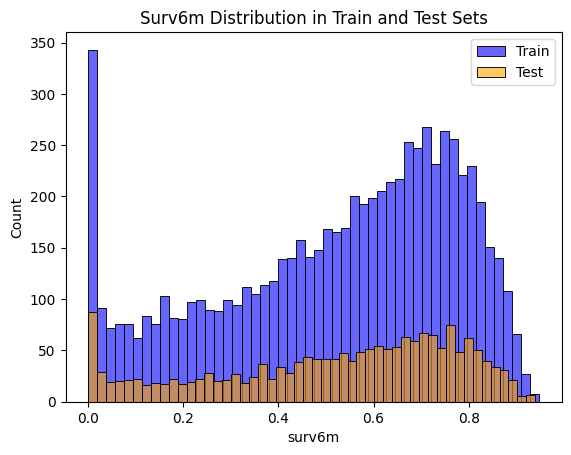

In [296]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(train_df['surv6m'], bins=50, color='blue', alpha=0.6, label='Train')
sns.histplot(test_df['surv6m'], bins=50, color='orange', alpha=0.6, label='Test')
plt.legend()
plt.title('Surv6m Distribution in Train and Test Sets')
plt.show()

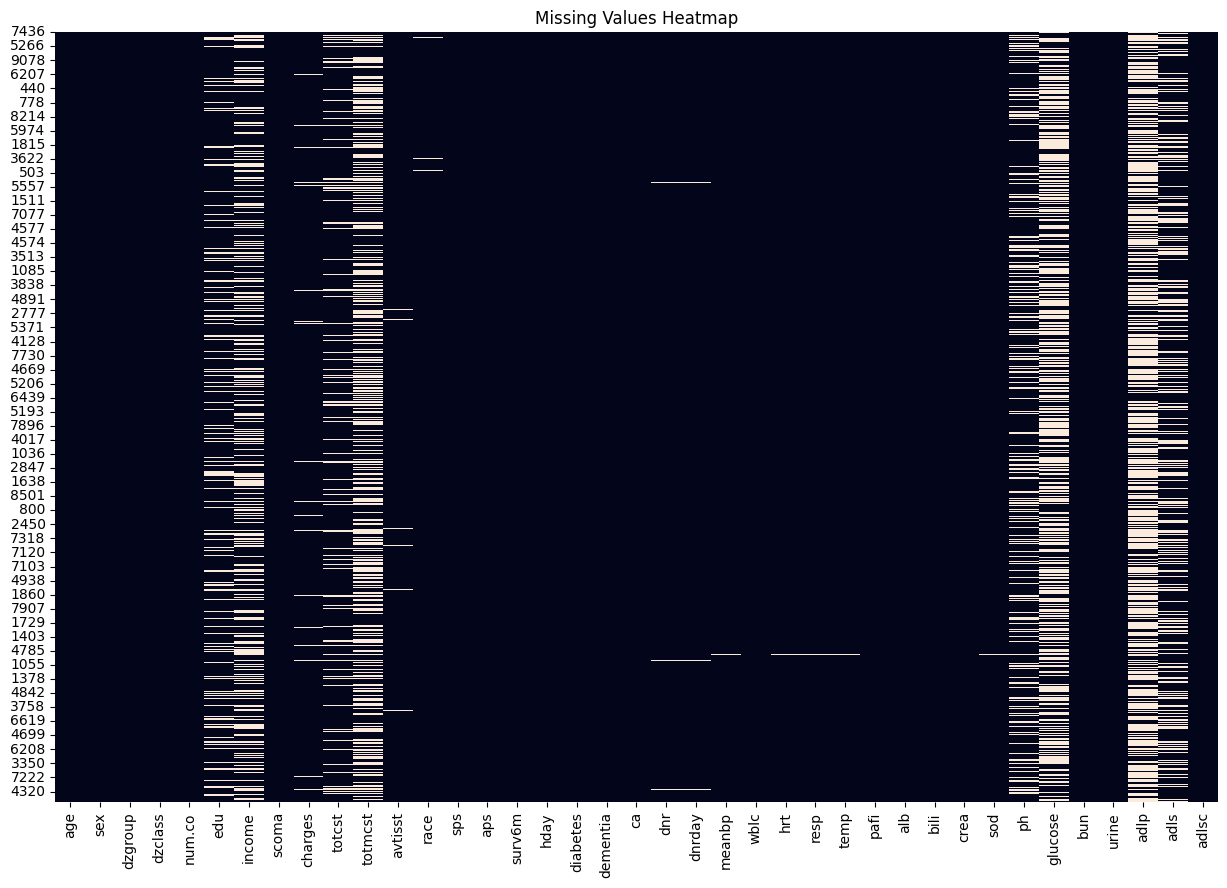

In [297]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))
sns.heatmap(train_df.isnull(), cbar=False)
plt.title('Missing Values Heatmap')
plt.show()

### The Skewed Candidates (Median Imputation)

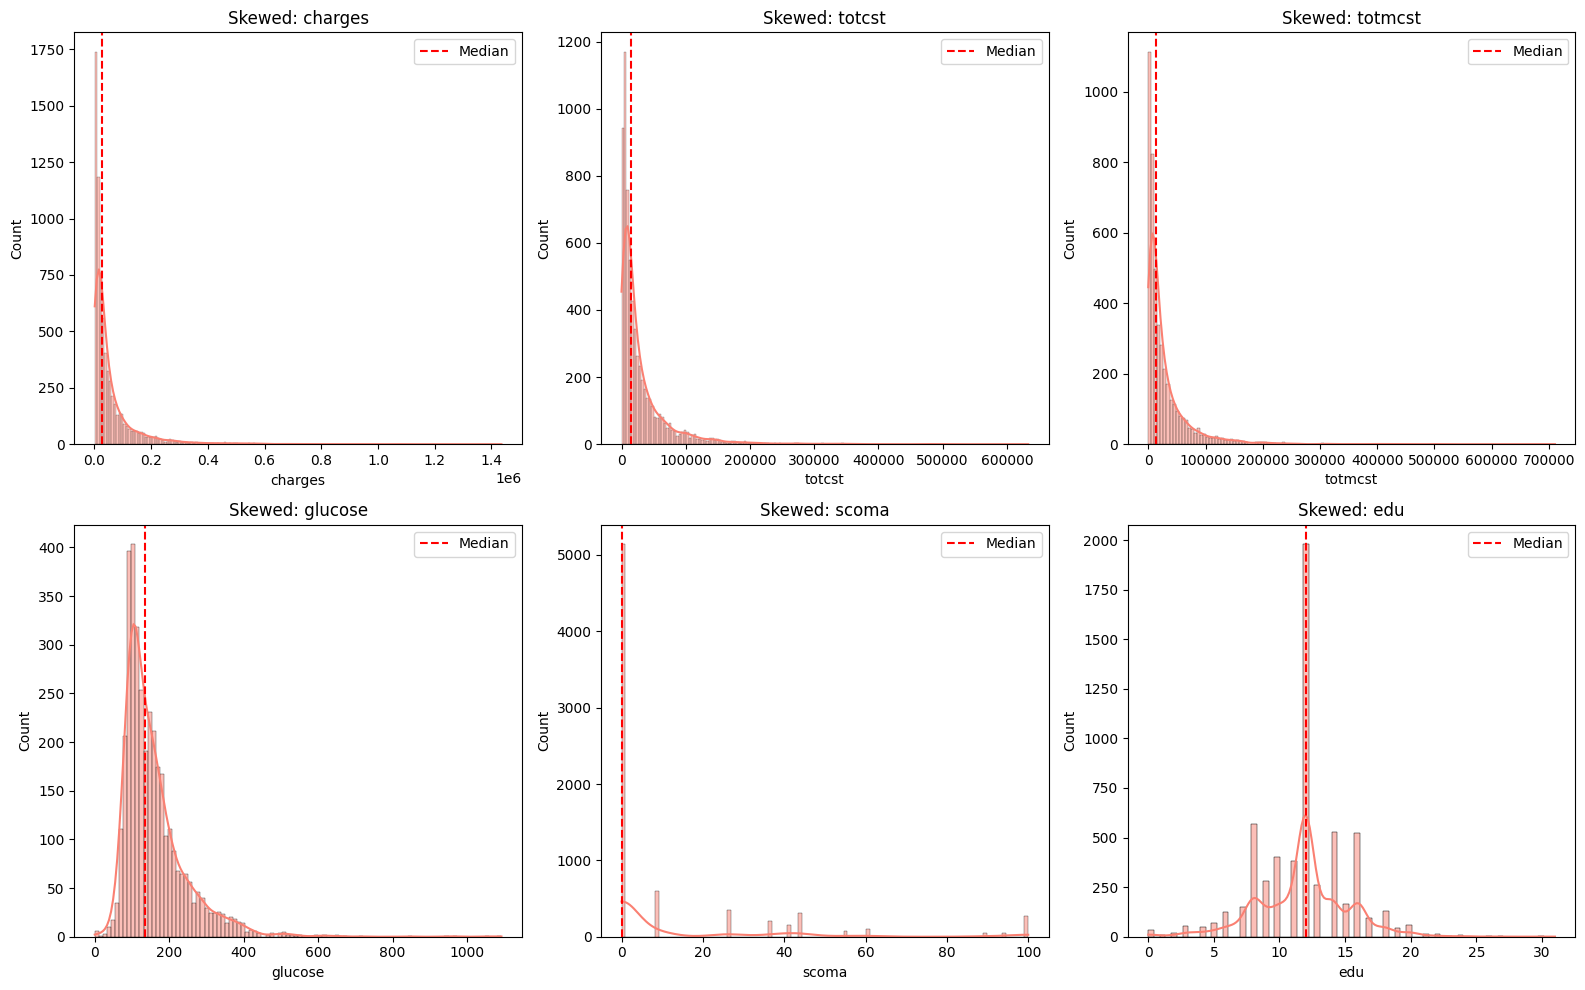

In [298]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grouping based on the 'long tail' seen in your previous plots
skewed_candidates = ['charges', 'totcst', 'totmcst', 'glucose', 'scoma', 'edu']

plt.figure(figsize=(16, 10))
for i, col in enumerate(skewed_candidates, 1):
    plt.subplot(2, 3, i)
    sns.histplot(train_df[col].dropna(), kde=True, color='salmon')
    plt.axvline(train_df[col].median(), color='red', linestyle='--', label='Median')
    plt.title(f'Skewed: {col}')
    plt.legend()

plt.tight_layout()
plt.show()

### The Symmetric & Bimodal Candidates - MICE Imputation

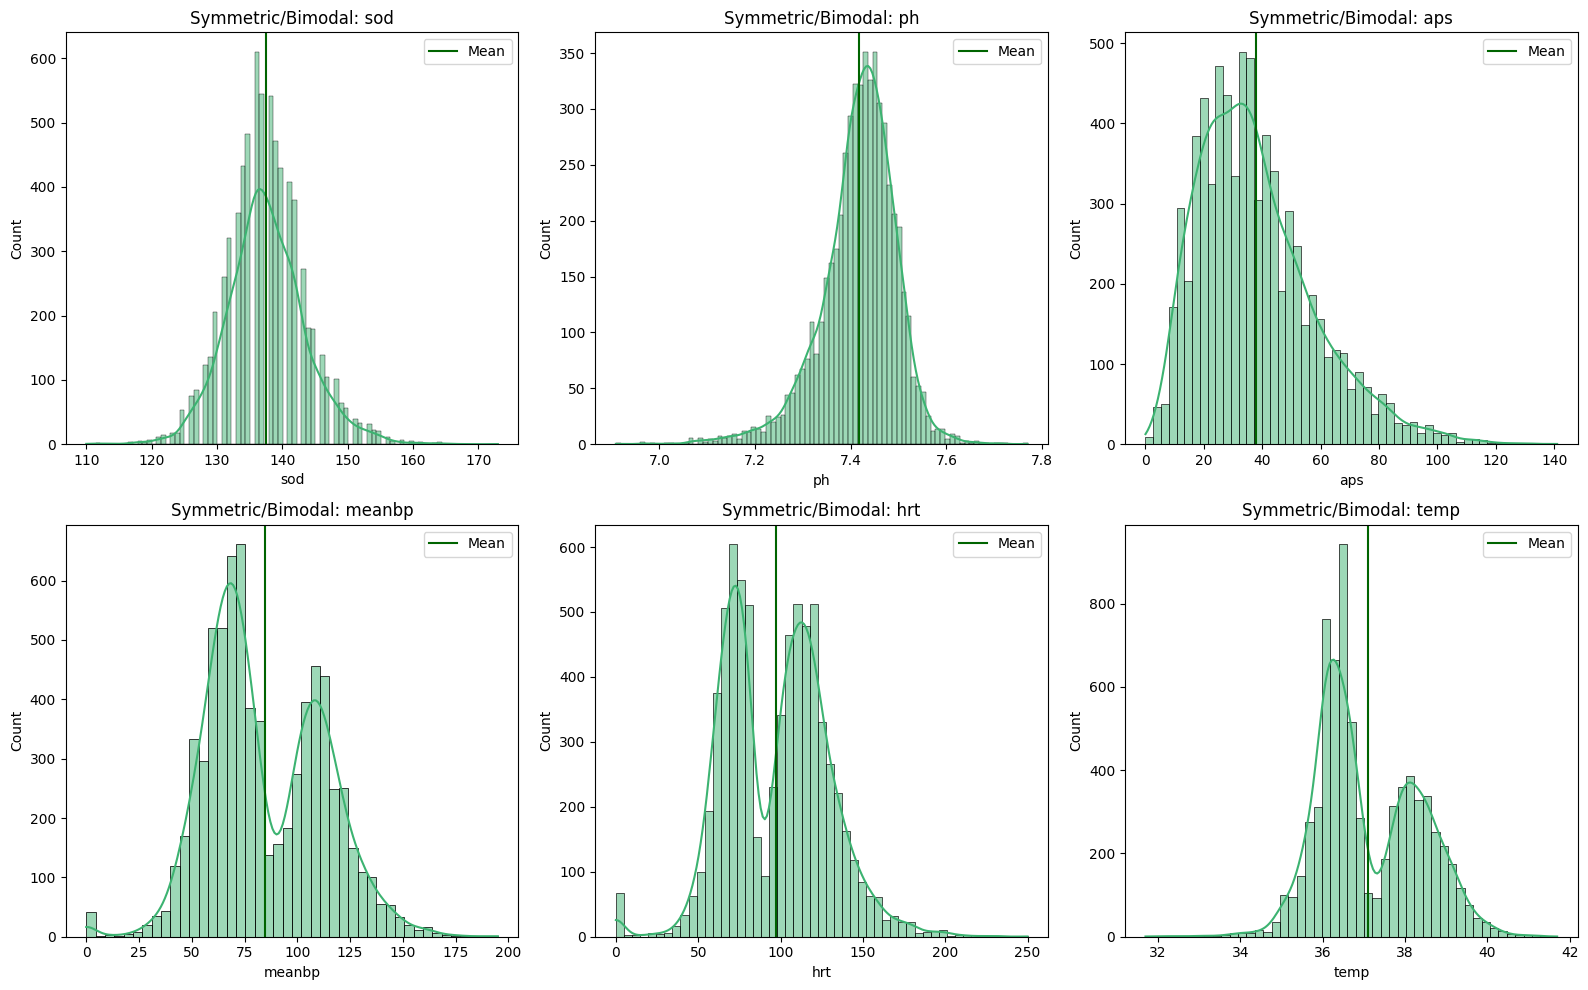

In [299]:
# sod and ph are symmetric; the others are clearly bimodal (two peaks)
complex_candidates = ['sod', 'ph', 'aps', 'meanbp', 'hrt', 'temp']

plt.figure(figsize=(16, 10))
for i, col in enumerate(complex_candidates, 1):
    plt.subplot(2, 3, i)
    sns.histplot(train_df[col].dropna(), kde=True, color='mediumseagreen')
    plt.axvline(train_df[col].mean(), color='darkgreen', linestyle='-', label='Mean')
    plt.title(f'Symmetric/Bimodal: {col}')
    plt.legend()

plt.tight_layout()
plt.show()

### The Categorical Candidates (Mode Imputation)

C:\Users\abdul\AppData\Local\Temp\ipykernel_10824\487882255.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x=col, order=order, palette='crest')
C:\Users\abdul\AppData\Local\Temp\ipykernel_10824\487882255.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x=col, order=order, palette='crest')
C:\Users\abdul\AppData\Local\Temp\ipykernel_10824\487882255.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x=col, order=order, palette='crest')


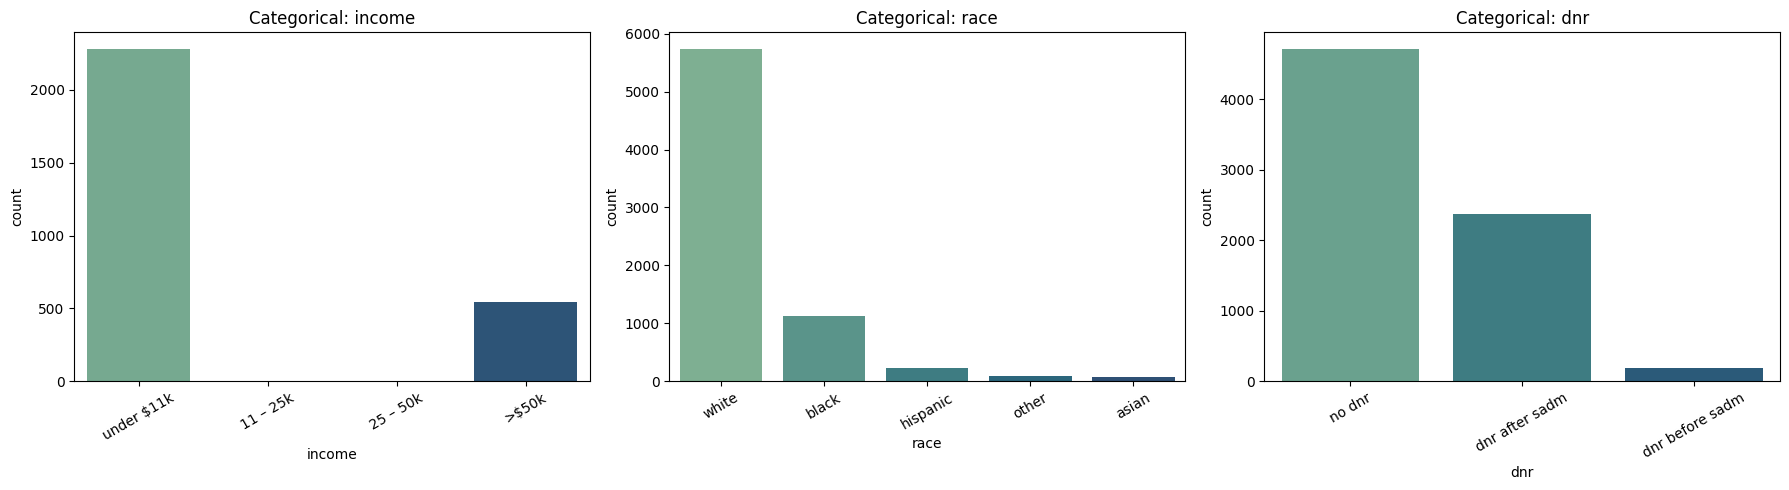

In [300]:
categorical_candidates = ['income', 'race', 'dnr']

plt.figure(figsize=(18, 5))
for i, col in enumerate(categorical_candidates, 1):
    plt.subplot(1, 3, i)
    # Using order to keep the income levels logical
    order = None
    if col == 'income':
        order = ['under $11k', '11 – 25k', '25 – 50k', '>$50k']
    
    sns.countplot(data=train_df, x=col, order=order, palette='crest')
    plt.title(f'Categorical: {col}')
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [301]:
from sklearn.impute import SimpleImputer

# 1. Define the candidates
skewed_candidates = ['charges', 'totcst', 'totmcst', 'glucose', 'scoma', 'edu']

# 2. Initialize the imputer with the median strategy
median_imputer = SimpleImputer(strategy='median')

# 3. Fit the imputer on the training data ONLY
# This calculates the median for each column in the training set
median_imputer.fit(train_df[skewed_candidates])

# 4. Transform both the training and test datasets
# This fills the missing values using the medians calculated in step 3
train_df[skewed_candidates] = median_imputer.transform(train_df[skewed_candidates])
test_df[skewed_candidates] = median_imputer.transform(test_df[skewed_candidates])

# 5. Verify that no missing values remain in these columns
print("Missing values in Train after imputation:")
print(train_df[skewed_candidates].isnull().sum())

print("\nMissing values in Test after imputation:")
print(test_df[skewed_candidates].isnull().sum())

Missing values in Train after imputation:
charges    0
totcst     0
totmcst    0
glucose    0
scoma      0
edu        0
dtype: int64

Missing values in Test after imputation:
charges    0
totcst     0
totmcst    0
glucose    0
scoma      0
edu        0
dtype: int64


In [302]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# 1. Define the candidates (Vitals/Lab values)
complex_candidates = ['sod', 'ph', 'aps', 'meanbp', 'hrt', 'temp']

# 2. Initialize the Iterative Imputer
# random_state ensures reproducibility; max_iter is the number of imputation rounds
mice_imputer = IterativeImputer(max_iter=10, random_state=42)

# 3. Fit ONLY on the training data to learn the relationships between vitals
mice_imputer.fit(train_df[complex_candidates])

# 4. Transform both datasets 
# This uses the "learned" relationships to fill the gaps in both sets
train_df[complex_candidates] = mice_imputer.transform(train_df[complex_candidates])
test_df[complex_candidates] = mice_imputer.transform(test_df[complex_candidates])

# 5. Quick Check for completion
print("Missing values in Complex Candidates (Train):")
print(train_df[complex_candidates].isnull().sum())

Missing values in Complex Candidates (Train):
sod       0
ph        0
aps       0
meanbp    0
hrt       0
temp      0
dtype: int64


In [303]:
from sklearn.impute import SimpleImputer

# 1. Define the categorical candidates
categorical_candidates = ['income', 'race', 'dnr']

# 2. Initialize the imputer with the "most_frequent" (Mode) strategy
mode_imputer = SimpleImputer(strategy='most_frequent')

# 3. Fit ONLY on the training data 
# This identifies the most common category for 'income', 'race', and 'dnr'
mode_imputer.fit(train_df[categorical_candidates])

# 4. Transform both datasets 
# This fills the strings in both sets using the training modes
train_df[categorical_candidates] = mode_imputer.transform(train_df[categorical_candidates])
test_df[categorical_candidates] = mode_imputer.transform(test_df[categorical_candidates])

# 5. Verification
print("Missing values in Categorical Candidates (Train):")
print(train_df[categorical_candidates].isnull().sum())

print("\nMissing values in Categorical Candidates (Test):")
print(test_df[categorical_candidates].isnull().sum())

Missing values in Categorical Candidates (Train):
income    0
race      0
dnr       0
dtype: int64

Missing values in Categorical Candidates (Test):
income    0
race      0
dnr       0
dtype: int64


### The only columns remaining from our original list are adlp (62% missing) and adls (31% missing). Given the extremely high missingness in adlp, it is often safer to drop it entirely to avoid introducing too much "noise" or "hallucinated" data into our model.

In [304]:
# 1. Define columns to drop due to high missingness (or lack of utility)
cols_to_drop = ['adlp', 'adls']

# 2. Drop the columns from both train and test to keep them synchronized
train_df = train_df.drop(columns=cols_to_drop)
test_df = test_df.drop(columns=cols_to_drop)

# 3. Final Verification: Check for any remaining null values in the entire dataframe
print("Total Missing Values in Train Set:")
print(train_df.isnull().sum().sum())

print("\nTotal Missing Values in Test Set:")
print(test_df.isnull().sum().sum())

# 4. Check the new shape of your data
print(f"\nNew Train Shape: {train_df.shape}")
print(f"New Test Shape: {test_df.shape}")

Total Missing Values in Train Set:
84

Total Missing Values in Test Set:
27

New Train Shape: (7283, 37)
New Test Shape: (1821, 37)


In [305]:
train_df

,age,sex,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,totmcst,avtisst,race,sps,aps,surv6m,hday,diabetes,dementia,ca,dnr,dnrday,meanbp,wblc,hrt,resp,temp,pafi,alb,bili,crea,sod,ph,glucose,bun,urine,adlsc
7436,44.27100,male,ARF/MOSF w/Sepsis,ARF/MOSF,2,15.0,$11-$25k,0.0,25203.000,15283.0938,17468.67190,41.000000,white,31.000000,40.0,0.704956,1,1,0,no,no dnr,9.0,124.0,19.597656,112.0,38.0,36.59375,290.0000,3.199707,0.199982,0.799927,138.0,7.469727,146.0,12.00,2206.0,2.000000
2668,41.16098,female,MOSF w/Malig,ARF/MOSF,2,12.0,$25-$50k,0.0,21183.000,8702.5938,12183.86720,17.000000,white,31.898438,53.0,0.345947,1,0,0,metastatic,dnr after sadm,3.0,73.0,9.599609,60.0,20.0,36.09375,358.3125,3.500000,1.010000,1.799805,137.0,7.349609,222.0,30.00,1850.0,1.000000
7049,41.29199,male,Colon Cancer,Cancer,1,12.0,under $11k,0.0,19689.000,13671.9922,15415.22660,14.666664,white,15.898438,15.0,0.702881,1,0,0,metastatic,no dnr,16.0,64.0,12.500000,67.0,35.0,36.89844,250.0000,3.500000,1.010000,0.699951,134.0,7.479492,191.0,22.00,2258.0,1.000000
8168,82.31299,male,Coma,Coma,0,8.0,under $11k,100.0,6698.000,4614.6250,4624.59766,57.000000,white,47.000000,51.0,0.000000,1,0,0,no,dnr after sadm,1.0,42.0,15.099609,114.0,20.0,35.89844,12.0000,3.000000,0.599976,1.399902,145.0,7.389648,136.0,6.51,2502.0,0.000000
5761,58.24197,male,COPD,COPD/CHF/Cirrhosis,2,12.0,under $11k,0.0,31389.000,14453.6250,13378.77340,29.000000,white,27.699219,33.0,0.687988,1,0,0,no,no dnr,9.0,117.0,7.500000,72.0,20.0,36.79688,333.3000,3.899902,0.500000,0.699951,136.0,7.427312,168.0,9.00,6100.0,2.666016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3837,33.98798,male,ARF/MOSF w/Sepsis,ARF/MOSF,0,12.0,$11-$25k,0.0,32652.094,21513.1094,13378.77340,12.000000,white,13.599609,12.0,0.919922,4,0,0,no,no dnr,11.0,107.0,8.798828,78.0,24.0,36.69531,348.9375,3.500000,1.010000,1.199951,137.0,7.409180,136.0,6.51,2502.0,0.000000
4201,37.50598,male,Coma,Coma,1,12.0,$11-$25k,61.0,69511.312,44734.5625,13378.77340,29.500000,white,20.000000,17.0,0.593994,23,0,0,no,dnr after sadm,2.0,113.0,4.500000,44.0,6.0,36.89844,547.5000,3.500000,1.010000,0.899902,154.0,7.429688,136.0,6.51,2502.0,2.008789
6847,77.85596,female,CHF,COPD/CHF/Cirrhosis,2,7.0,under $11k,0.0,6140.000,4446.1875,5399.77734,23.000000,black,15.298828,19.0,0.681885,1,0,0,metastatic,dnr after sadm,7.0,64.0,12.298828,120.0,37.0,39.09375,160.0000,2.500000,0.699951,1.599854,132.0,7.429688,114.0,22.00,1810.0,0.000000
7860,76.38098,male,Colon Cancer,Cancer,1,9.0,under $11k,0.0,20869.000,15689.7109,14394.98440,19.000000,white,14.599609,16.0,0.626953,1,0,0,metastatic,dnr after sadm,16.0,98.0,8.699219,82.0,20.0,36.59375,333.3000,3.500000,1.010000,1.299805,136.0,7.427015,136.0,6.51,2502.0,0.000000


In [306]:
# 1. Select only the columns with 'object' (string) data types
string_cols = train_df.select_dtypes(include=['object']).columns

# 2. Display the list and the number of unique values in each
print("Columns currently in string format:")
for col in string_cols:
    unique_count = train_df[col].nunique()
    print(f"- {col}: {unique_count} unique categories")

# 3. Preview the first few rows of these columns to see the labels
print("\nPreview of string data:")
print(train_df[string_cols].head())

Columns currently in string format:
- sex: 2 unique categories
- dzgroup: 8 unique categories
- dzclass: 4 unique categories
- income: 4 unique categories
- race: 5 unique categories
- ca: 3 unique categories
- dnr: 3 unique categories

Preview of string data:
         sex            dzgroup             dzclass      income   race  \
7436    male  ARF/MOSF w/Sepsis            ARF/MOSF    $11-$25k  white   
2668  female       MOSF w/Malig            ARF/MOSF    $25-$50k  white   
7049    male       Colon Cancer              Cancer  under $11k  white   
8168    male               Coma                Coma  under $11k  white   
5761    male               COPD  COPD/CHF/Cirrhosis  under $11k  white   

              ca             dnr  
7436          no          no dnr  
2668  metastatic  dnr after sadm  
7049  metastatic          no dnr  
8168          no  dnr after sadm  
5761          no          no dnr  


C:\Users\abdul\AppData\Local\Temp\ipykernel_10824\2906383071.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = train_df.select_dtypes(include=['object']).columns


In [307]:
# train_df["sex"].unique()
# 
#train_df["dzclass"].unique()
# train_df["sex"].unique()
# train_df["income"].unique()
# train_df["ca"].unique()
# train_df["race"].unique()
# train_df["dnr"].unique()

In [308]:
train_df.drop(columns=['dzgroup'], inplace=True)
test_df.drop(columns=['dzgroup'], inplace=True)

## Manual Mapping for Ordinal Features

In [309]:
# Define the order for ordinal columns
income_map = {
    'under $11k': 0, 
    '$11-$25k': 1, 
    '$25-$50k': 2, 
    '>$50k': 3
}

ca_map = {
    'no': 0, 
    'yes': 1, 
    'metastatic': 2
}

# Apply mapping to both train and test
for df in [train_df, test_df]:
    df['income'] = df['income'].map(income_map)
    df['ca'] = df['ca'].map(ca_map)
    # Simple binary encoding for sex
    df['sex'] = df['sex'].map({'male': 0, 'female': 1})

# One-Hot Encoding for Nominal Features

In [310]:
nominal_cols = ['dzclass', 'race', 'dnr']

# Apply One-Hot Encoding
train_df = pd.get_dummies(train_df, columns=nominal_cols, drop_first=True)
test_df = pd.get_dummies(test_df, columns=nominal_cols, drop_first=True)

# Important: Ensure train and test have the exact same columns after encoding
# (Sometimes a category exists in train but not test)
train_df, test_df = train_df.align(test_df, join='left', axis=1, fill_value=0)

print(f"Final features count: {train_df.shape[1]}")
print(train_df.head())

Final features count: 42
           age  sex  num.co   edu  income  scoma  charges      totcst  \
7436  44.27100    0       2  15.0       1    0.0  25203.0  15283.0938   
2668  41.16098    1       2  12.0       2    0.0  21183.0   8702.5938   
7049  41.29199    0       1  12.0       0    0.0  19689.0  13671.9922   
8168  82.31299    0       0   8.0       0  100.0   6698.0   4614.6250   
5761  58.24197    0       2  12.0       0    0.0  31389.0  14453.6250   

          totmcst    avtisst        sps   aps    surv6m  hday  diabetes  \
7436  17468.67190  41.000000  31.000000  40.0  0.704956     1         1   
2668  12183.86720  17.000000  31.898438  53.0  0.345947     1         0   
7049  15415.22660  14.666664  15.898438  15.0  0.702881     1         0   
8168   4624.59766  57.000000  47.000000  51.0  0.000000     1         0   
5761  13378.77340  29.000000  27.699219  33.0  0.687988     1         0   

      dementia  ca  dnrday  meanbp       wblc    hrt  resp      temp  \
7436         

In [311]:
train_df.isnull().sum()

age                            0
sex                            0
num.co                         0
edu                            0
income                         0
scoma                          0
charges                        0
totcst                         0
totmcst                        0
avtisst                       63
sps                            0
aps                            0
surv6m                         0
hday                           0
diabetes                       0
dementia                       0
ca                             0
dnrday                        20
meanbp                         0
wblc                           0
hrt                            0
resp                           1
temp                           0
pafi                           0
alb                            0
bili                           0
crea                           0
sod                            0
ph                             0
glucose                        0
bun       

In [312]:
test_df.isnull().sum()

age                            0
sex                            0
num.co                         0
edu                            0
income                         0
scoma                          0
charges                        0
totcst                         0
totmcst                        0
avtisst                       18
sps                            0
aps                            0
surv6m                         0
hday                           0
diabetes                       0
dementia                       0
ca                             0
dnrday                         9
meanbp                         0
wblc                           0
hrt                            0
resp                           0
temp                           0
pafi                           0
alb                            0
bili                           0
crea                           0
sod                            0
ph                             0
glucose                        0
bun       

In [313]:
# train_df.drop(columns=['avtisst'], inplace=True)
# test_df.drop(columns=['avtisst'], inplace=True)

# train_df.drop(columns=['dnrday'], inplace=True)
# test_df.drop(columns=['dnrday'], inplace=True)


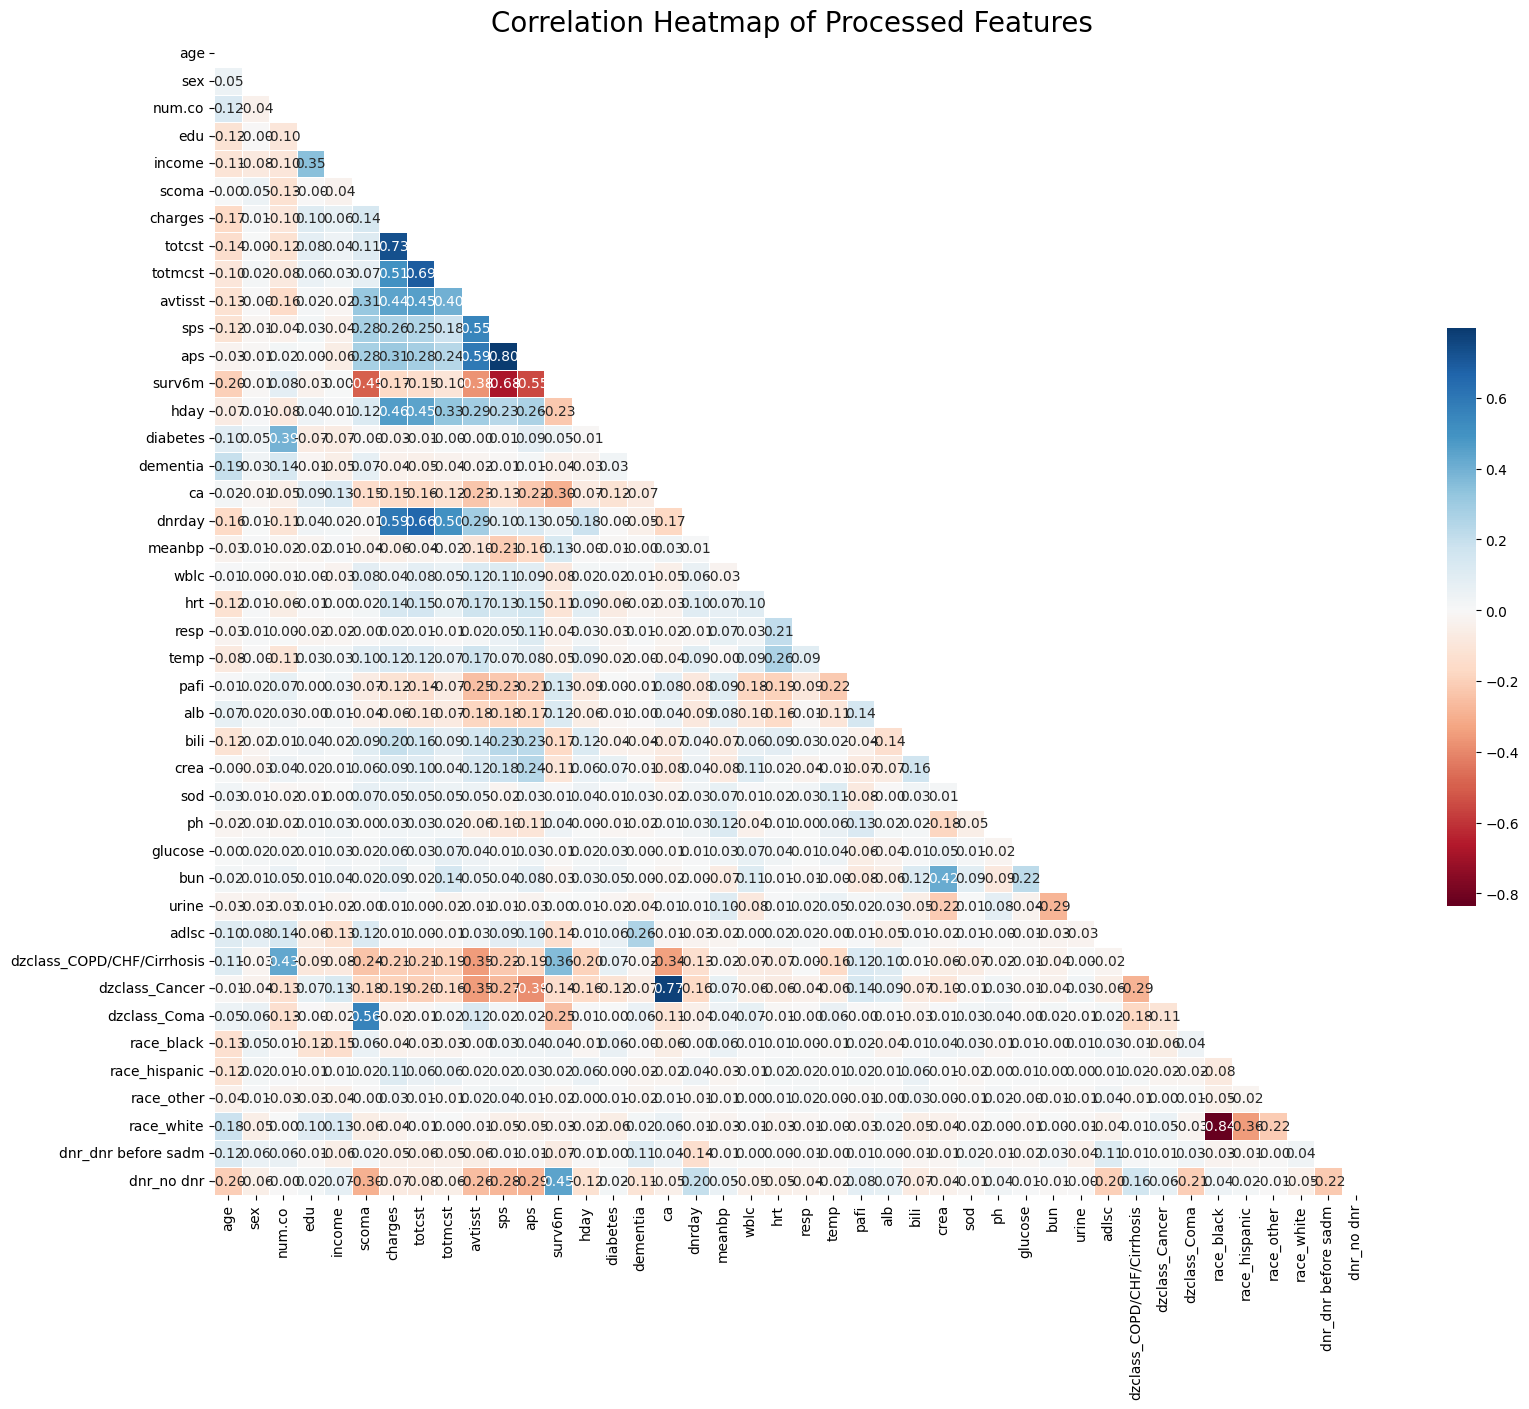

In [314]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Compute the correlation matrix
corr_matrix = train_df.corr()

# Generate a mask for the upper triangle (optional, makes it cleaner)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='RdBu', center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

plt.title('Correlation Heatmap of Processed Features', fontsize=20)
plt.show()

### The Redundancy Analysis

race_white vs race_black: Drop race_black. This high correlation is likely a side effect of One-Hot Encoding in a dataset where these are the two primary groups. Keeping both is redundant for the model.

aps vs sps: Drop sps. Both measure physiology/severity. aps (Acute Physiology Score) is generally more standard in clinical modeling. Keeping both creates multicollinearity in "sickness" metrics.

dzclass_Cancer vs ca: Drop dzclass_Cancer. our ca (cancer status) variable is more granular (none, yes, metastatic). It already captures the information dzclass provides.

totcst vs charges: Drop totcst (Total Cost). charges and totcst are basically measuring the same financial outcome. charges often has slightly more variance which is better for models.

In [315]:
# 1. Compute the correlation matrix
corr_matrix = train_df.corr().abs()

# 2. Select the upper triangle (to avoid duplicate pairs like A-B and B-A)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 3. Flatten the matrix and sort
# We filter for correlations > 0.7, which is a common threshold for "high correlation"
high_corr = upper.unstack().dropna()
high_corr = high_corr[high_corr > 0.7].sort_values(ascending=False)

# 4. Represent as a clean DataFrame
high_corr_df = pd.DataFrame(high_corr).reset_index()
high_corr_df.columns = ['Feature 1', 'Feature 2', 'Correlation (r)']

print("Top Mathematically Significant Correlations (|r| > 0.7):")
print(high_corr_df)

Top Mathematically Significant Correlations (|r| > 0.7):
        Feature 1   Feature 2  Correlation (r)
0      race_white  race_black         0.835296
1             aps         sps         0.797016
2  dzclass_Cancer          ca         0.772146
3          totcst     charges         0.733140


In [316]:
# List of features to drop based on high correlation and redundancy
redundant_cols = ['race_black', 'sps', 'dzclass_Cancer', 'totcst']

# Drop from both dataframes
train_df = train_df.drop(columns=redundant_cols)
test_df = test_df.drop(columns=redundant_cols)

print(f"Features remaining: {len(train_df.columns)}")

Features remaining: 38


# VIF CALCULATION

### Why these results are "Healthy":

VIF Scores < 5: Every single predictor now has a VIF well below the common threshold of 5 (and even the stricter threshold of 2.5 for most). This means our features are independent, and each one provides unique information to the model.

Target Stability: Our target variable (surv6m) now has a VIF of 3.56. This is perfectly normal; it simply indicates that our predictors actually have a relationship with the outcome WE ARE trying to forecast—which is exactly what we want!

In [317]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

def calculate_vif_clean(df):
    # 1. Ensure only numeric types are passed
    numeric_df = df.select_dtypes(include=[np.number])
    
    # 2. Handle NaNs and Infs (VIF cannot handle these)
    # Filling NaNs with 0 and replacing Infs with 0 just for the VIF calculation
    numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan).fillna(0)
    
    # 3. Add a constant column (intercept)
    # VIF is based on R^2 of regressing one feature on others; it needs an intercept
    X = numeric_df.assign(const=1)
    
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    
    # 4. Calculate VIF
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    
    # Drop the constant row and sort
    return vif_data[vif_data['feature'] != 'const'].sort_values(by="VIF", ascending=False)

# Run it on your train_df
vif_results = calculate_vif_clean(train_df)
print(vif_results)

     feature       VIF
10    surv6m  3.568824
9        aps  2.654822
6    charges  2.282807
8    avtisst  2.099679
14        ca  1.948929
15    dnrday  1.881138
5      scoma  1.747402
7    totmcst  1.649129
28       bun  1.414632
11      hday  1.383581
24      crea  1.361246
0        age  1.330414
2     num.co  1.329045
12  diabetes  1.236084
18       hrt  1.212314
21      pafi  1.193596
4     income  1.191474
3        edu  1.170608
20      temp  1.168744
23      bili  1.154485
30     adlsc  1.136505
13  dementia  1.132812
29     urine  1.127763
22       alb  1.100641
16    meanbp  1.094109
26        ph  1.085748
19      resp  1.080190
17      wblc  1.074785
27   glucose  1.067080
25       sod  1.054322
1        sex  1.029769


In [318]:
train_df

,age,sex,num.co,edu,income,scoma,charges,totmcst,avtisst,aps,surv6m,hday,diabetes,dementia,ca,dnrday,meanbp,wblc,hrt,resp,temp,pafi,alb,bili,crea,sod,ph,glucose,bun,urine,adlsc,dzclass_COPD/CHF/Cirrhosis,dzclass_Coma,race_hispanic,race_other,race_white,dnr_dnr before sadm,dnr_no dnr
7436,44.27100,0,2,15.0,1,0.0,25203.000,17468.67190,41.000000,40.0,0.704956,1,1,0,0,9.0,124.0,19.597656,112.0,38.0,36.59375,290.0000,3.199707,0.199982,0.799927,138.0,7.469727,146.0,12.00,2206.0,2.000000,False,False,False,False,True,False,True
2668,41.16098,1,2,12.0,2,0.0,21183.000,12183.86720,17.000000,53.0,0.345947,1,0,0,2,3.0,73.0,9.599609,60.0,20.0,36.09375,358.3125,3.500000,1.010000,1.799805,137.0,7.349609,222.0,30.00,1850.0,1.000000,False,False,False,False,True,False,False
7049,41.29199,0,1,12.0,0,0.0,19689.000,15415.22660,14.666664,15.0,0.702881,1,0,0,2,16.0,64.0,12.500000,67.0,35.0,36.89844,250.0000,3.500000,1.010000,0.699951,134.0,7.479492,191.0,22.00,2258.0,1.000000,False,False,False,False,True,False,True
8168,82.31299,0,0,8.0,0,100.0,6698.000,4624.59766,57.000000,51.0,0.000000,1,0,0,0,1.0,42.0,15.099609,114.0,20.0,35.89844,12.0000,3.000000,0.599976,1.399902,145.0,7.389648,136.0,6.51,2502.0,0.000000,False,True,False,False,True,False,False
5761,58.24197,0,2,12.0,0,0.0,31389.000,13378.77340,29.000000,33.0,0.687988,1,0,0,0,9.0,117.0,7.500000,72.0,20.0,36.79688,333.3000,3.899902,0.500000,0.699951,136.0,7.427312,168.0,9.00,6100.0,2.666016,True,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3837,33.98798,0,0,12.0,1,0.0,32652.094,13378.77340,12.000000,12.0,0.919922,4,0,0,0,11.0,107.0,8.798828,78.0,24.0,36.69531,348.9375,3.500000,1.010000,1.199951,137.0,7.409180,136.0,6.51,2502.0,0.000000,False,False,False,False,True,False,True
4201,37.50598,0,1,12.0,1,61.0,69511.312,13378.77340,29.500000,17.0,0.593994,23,0,0,0,2.0,113.0,4.500000,44.0,6.0,36.89844,547.5000,3.500000,1.010000,0.899902,154.0,7.429688,136.0,6.51,2502.0,2.008789,False,True,False,False,True,False,False
6847,77.85596,1,2,7.0,0,0.0,6140.000,5399.77734,23.000000,19.0,0.681885,1,0,0,2,7.0,64.0,12.298828,120.0,37.0,39.09375,160.0000,2.500000,0.699951,1.599854,132.0,7.429688,114.0,22.00,1810.0,0.000000,True,False,False,False,False,False,False
7860,76.38098,0,1,9.0,0,0.0,20869.000,14394.98440,19.000000,16.0,0.626953,1,0,0,2,16.0,98.0,8.699219,82.0,20.0,36.59375,333.3000,3.500000,1.010000,1.299805,136.0,7.427015,136.0,6.51,2502.0,0.000000,False,False,False,False,True,False,False


In [319]:
test_df

,age,sex,num.co,edu,income,scoma,charges,totmcst,avtisst,aps,surv6m,hday,diabetes,dementia,ca,dnrday,meanbp,wblc,hrt,resp,temp,pafi,alb,bili,crea,sod,ph,glucose,bun,urine,adlsc,dzclass_COPD/CHF/Cirrhosis,dzclass_Coma,race_hispanic,race_other,race_white,dnr_dnr before sadm,dnr_no dnr
2932,49.45398,1,2,12.0,2,0.0,12241.000,2776.16992,11.000000,12.0,0.676880,1,0,0,2,4.0,49.0,5.699219,107.0,28.0,38.89844,287.50000,3.500000,0.599976,1.399902,142.0,7.429688,110.0,35.00,2710.0,0.494751,False,False,False,False,True,False,True
2386,84.51996,1,4,13.0,1,0.0,5884.000,13378.77340,10.000000,30.0,0.614990,1,0,0,1,5.0,117.0,9.298828,45.0,28.0,36.69531,223.31250,3.199707,0.399963,1.199951,143.0,7.369141,136.0,6.51,2502.0,0.000000,True,False,False,False,True,False,True
5366,28.14200,0,1,8.0,0,0.0,660091.000,13378.77340,55.750000,81.0,0.461975,1,0,0,0,152.0,133.0,19.296875,115.0,22.0,39.00000,362.81250,3.500000,1.010000,1.199951,151.0,7.529297,134.0,24.00,2232.0,0.000000,False,False,False,True,False,False,True
3095,63.22198,0,4,13.0,0,0.0,11623.000,5021.25781,5.500000,13.0,0.683960,1,1,0,0,8.0,43.0,11.699219,70.0,20.0,35.59375,135.00000,3.500000,1.010000,2.000000,139.0,7.439453,93.0,54.00,1075.0,3.000000,True,False,False,False,True,False,True
5107,65.89697,1,3,7.0,0,9.0,58303.000,31352.00000,33.000000,68.0,0.353943,10,1,0,0,5.0,107.0,5.199219,108.0,20.0,36.50000,257.12500,3.799805,0.500000,1.199951,128.0,7.469727,105.0,33.00,1025.0,6.000000,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3841,62.60397,0,1,16.0,1,0.0,6939.148,13378.77340,8.500000,11.0,0.727905,1,0,0,2,8.0,113.0,4.299805,66.0,16.0,37.69531,333.30000,3.599609,0.599976,1.099854,139.0,7.434257,136.0,6.51,2502.0,0.000000,False,False,False,False,True,False,True
3502,53.25098,0,2,12.0,1,26.0,83062.625,13378.77340,38.500000,26.0,0.611938,10,1,0,0,10.0,87.0,10.898438,92.0,8.0,37.19531,116.35938,3.500000,1.010000,1.500000,145.0,7.419922,136.0,6.51,2502.0,2.000000,False,False,False,False,True,False,False
802,65.92999,1,4,12.0,0,0.0,60355.000,13378.77340,12.333328,29.0,0.692993,1,1,0,1,16.0,63.0,7.099609,50.0,20.0,36.50000,333.30000,3.500000,1.010000,2.099609,140.0,7.410320,136.0,6.51,2502.0,1.839000,True,False,False,False,True,False,True
8296,53.34698,0,3,12.0,2,0.0,3856.000,2108.17969,8.000000,18.0,0.265991,1,0,0,2,5.0,109.0,12.599609,122.0,20.0,36.19531,333.30000,3.500000,0.299988,0.699951,132.0,7.430791,136.0,6.51,2502.0,0.000000,False,False,False,False,True,False,True


In [ ]:
train_df.drop(columns=['dnrday'], inplace=True)
test_df.drop(columns=['dnrday'], inplace=True)


train_df.drop(columns=['dnr_no dnr'], inplace=True)
test_df.drop(columns=['dnr_no dnr'], inplace=True)

In [321]:
train_df

,age,sex,num.co,edu,income,scoma,charges,totmcst,avtisst,aps,surv6m,hday,diabetes,dementia,ca,meanbp,wblc,hrt,resp,temp,pafi,alb,bili,crea,sod,ph,glucose,bun,urine,adlsc,dzclass_COPD/CHF/Cirrhosis,dzclass_Coma,race_hispanic,race_other,race_white,dnr_dnr before sadm
7436,44.27100,0,2,15.0,1,0.0,25203.000,17468.67190,41.000000,40.0,0.704956,1,1,0,0,124.0,19.597656,112.0,38.0,36.59375,290.0000,3.199707,0.199982,0.799927,138.0,7.469727,146.0,12.00,2206.0,2.000000,False,False,False,False,True,False
2668,41.16098,1,2,12.0,2,0.0,21183.000,12183.86720,17.000000,53.0,0.345947,1,0,0,2,73.0,9.599609,60.0,20.0,36.09375,358.3125,3.500000,1.010000,1.799805,137.0,7.349609,222.0,30.00,1850.0,1.000000,False,False,False,False,True,False
7049,41.29199,0,1,12.0,0,0.0,19689.000,15415.22660,14.666664,15.0,0.702881,1,0,0,2,64.0,12.500000,67.0,35.0,36.89844,250.0000,3.500000,1.010000,0.699951,134.0,7.479492,191.0,22.00,2258.0,1.000000,False,False,False,False,True,False
8168,82.31299,0,0,8.0,0,100.0,6698.000,4624.59766,57.000000,51.0,0.000000,1,0,0,0,42.0,15.099609,114.0,20.0,35.89844,12.0000,3.000000,0.599976,1.399902,145.0,7.389648,136.0,6.51,2502.0,0.000000,False,True,False,False,True,False
5761,58.24197,0,2,12.0,0,0.0,31389.000,13378.77340,29.000000,33.0,0.687988,1,0,0,0,117.0,7.500000,72.0,20.0,36.79688,333.3000,3.899902,0.500000,0.699951,136.0,7.427312,168.0,9.00,6100.0,2.666016,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3837,33.98798,0,0,12.0,1,0.0,32652.094,13378.77340,12.000000,12.0,0.919922,4,0,0,0,107.0,8.798828,78.0,24.0,36.69531,348.9375,3.500000,1.010000,1.199951,137.0,7.409180,136.0,6.51,2502.0,0.000000,False,False,False,False,True,False
4201,37.50598,0,1,12.0,1,61.0,69511.312,13378.77340,29.500000,17.0,0.593994,23,0,0,0,113.0,4.500000,44.0,6.0,36.89844,547.5000,3.500000,1.010000,0.899902,154.0,7.429688,136.0,6.51,2502.0,2.008789,False,True,False,False,True,False
6847,77.85596,1,2,7.0,0,0.0,6140.000,5399.77734,23.000000,19.0,0.681885,1,0,0,2,64.0,12.298828,120.0,37.0,39.09375,160.0000,2.500000,0.699951,1.599854,132.0,7.429688,114.0,22.00,1810.0,0.000000,True,False,False,False,False,False
7860,76.38098,0,1,9.0,0,0.0,20869.000,14394.98440,19.000000,16.0,0.626953,1,0,0,2,98.0,8.699219,82.0,20.0,36.59375,333.3000,3.500000,1.010000,1.299805,136.0,7.427015,136.0,6.51,2502.0,0.000000,False,False,False,False,True,False


In [322]:
test_df

,age,sex,num.co,edu,income,scoma,charges,totmcst,avtisst,aps,surv6m,hday,diabetes,dementia,ca,meanbp,wblc,hrt,resp,temp,pafi,alb,bili,crea,sod,ph,glucose,bun,urine,adlsc,dzclass_COPD/CHF/Cirrhosis,dzclass_Coma,race_hispanic,race_other,race_white,dnr_dnr before sadm
2932,49.45398,1,2,12.0,2,0.0,12241.000,2776.16992,11.000000,12.0,0.676880,1,0,0,2,49.0,5.699219,107.0,28.0,38.89844,287.50000,3.500000,0.599976,1.399902,142.0,7.429688,110.0,35.00,2710.0,0.494751,False,False,False,False,True,False
2386,84.51996,1,4,13.0,1,0.0,5884.000,13378.77340,10.000000,30.0,0.614990,1,0,0,1,117.0,9.298828,45.0,28.0,36.69531,223.31250,3.199707,0.399963,1.199951,143.0,7.369141,136.0,6.51,2502.0,0.000000,True,False,False,False,True,False
5366,28.14200,0,1,8.0,0,0.0,660091.000,13378.77340,55.750000,81.0,0.461975,1,0,0,0,133.0,19.296875,115.0,22.0,39.00000,362.81250,3.500000,1.010000,1.199951,151.0,7.529297,134.0,24.00,2232.0,0.000000,False,False,False,True,False,False
3095,63.22198,0,4,13.0,0,0.0,11623.000,5021.25781,5.500000,13.0,0.683960,1,1,0,0,43.0,11.699219,70.0,20.0,35.59375,135.00000,3.500000,1.010000,2.000000,139.0,7.439453,93.0,54.00,1075.0,3.000000,True,False,False,False,True,False
5107,65.89697,1,3,7.0,0,9.0,58303.000,31352.00000,33.000000,68.0,0.353943,10,1,0,0,107.0,5.199219,108.0,20.0,36.50000,257.12500,3.799805,0.500000,1.199951,128.0,7.469727,105.0,33.00,1025.0,6.000000,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3841,62.60397,0,1,16.0,1,0.0,6939.148,13378.77340,8.500000,11.0,0.727905,1,0,0,2,113.0,4.299805,66.0,16.0,37.69531,333.30000,3.599609,0.599976,1.099854,139.0,7.434257,136.0,6.51,2502.0,0.000000,False,False,False,False,True,False
3502,53.25098,0,2,12.0,1,26.0,83062.625,13378.77340,38.500000,26.0,0.611938,10,1,0,0,87.0,10.898438,92.0,8.0,37.19531,116.35938,3.500000,1.010000,1.500000,145.0,7.419922,136.0,6.51,2502.0,2.000000,False,False,False,False,True,False
802,65.92999,1,4,12.0,0,0.0,60355.000,13378.77340,12.333328,29.0,0.692993,1,1,0,1,63.0,7.099609,50.0,20.0,36.50000,333.30000,3.500000,1.010000,2.099609,140.0,7.410320,136.0,6.51,2502.0,1.839000,True,False,False,False,True,False
8296,53.34698,0,3,12.0,2,0.0,3856.000,2108.17969,8.000000,18.0,0.265991,1,0,0,2,109.0,12.599609,122.0,20.0,36.19531,333.30000,3.500000,0.299988,0.699951,132.0,7.430791,136.0,6.51,2502.0,0.000000,False,False,False,False,True,False


# SANITYYY CHECKKKK
MODEL ALREADY CAPTURING 81% OF THE VARIANCE IN THE DATA EZZZZZZZZZZZZZZ

In [323]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Split features & target
X_train = train_df.drop(columns=['surv6m'])
y_train = train_df['surv6m']

X_test = test_df.drop(columns=['surv6m'])
y_test = test_df['surv6m']

# Model
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.08033671422291566
MSE: 0.0117953750719779
RMSE: 0.10860651486894282
R2: 0.8170256852541218


In [324]:
print(train_df.corr()['surv6m'].sort_values(ascending=False).head(10))

surv6m                        1.000000
dzclass_COPD/CHF/Cirrhosis    0.359349
pafi                          0.131466
meanbp                        0.127741
alb                           0.117172
num.co                        0.081270
diabetes                      0.046979
ph                            0.042186
race_hispanic                 0.018416
sod                           0.011542
Name: surv6m, dtype: float64


In [ ]:
train_df.to_csv('datasets/train_df_processed.csv', index=False)
test_df.to_csv('datasets/test_df_processed.csv', index=False)
